# **Customer Purchasing Behaviour and Operational Performance Analysis for an E-Commerce Platform**

Student Name: **Nikhil Gopi**

Matriculation Number: **GH1059131**

Course Name: **Data Science, AI, and Digital Business**

Module: **M505C Intro to AI and Machine Learning**

Date: **18.09.2026**

# 1. Business Understanding

### 1.1 Company Profile

Company Name : **Xxcort Essentials GmbH**

Industry : **E-Commerce and Digital Retail**

Headquarters : **Berlin, Germany**

Business Model : **Business-to-Consumer (B2C) Online Marketplace**

### 1.2 Company Overview
Xxcort Essentials GmbH is a digital retailer with an online marketplace in which customers can find numerous independent retailers. This platform sells items in several categories such as home products, electronics, fashion, beauty and lifestyle items, The success of its business relies on efficient order fullfilment, reliable delivery and good customer shopping exeperience.

### 1.3 Business Problem
As the busines expands, management must become more aware of the factors that contribute to revenue, customer satisfaction, and operational performance. While a lot of data is gathered daily on transactions, they are present in various datasets and not directly actionalble for business. The firm is looking to find which products and locations are most effective, enhance delivery performance and enable data-driven decisions.

### 1.4 Project Objectives
This project seeks to anayse the e-commerce data and provide business insights that will be used for tactical or stratgic decisions.

Main Objectives are;
* To identify the product categories that generate the highest revenue to the business.
* To measure and compare revenues by customer state and city.
* To learn customer spending patterns and payment preferences.
* To examine the seasonal trends in sales and buying.
* To calculate te effect of delay to customer's satisfaction.
* To determine which categories and vendors are related to late deliveries.
* To assess the operational performances by examining the status of orders and results of deliveres.

### 1.5 Expected Business Value
The results will cntribute to an improved product investment decision making for XXcort Essentials GmbH, optimize their logistics processes, reinforce their regional growth plans, increase customer satisfaction and help them to make more effective business plans based on data-driven insights.

# 2. Data Collection
The Olist E-Commerce Dataset is a publicly available transcational dataset from Kaggle that will be used in this project. The dataset includes real-world data from online marketplaces such as customer orders, products, payments, reviews, sellers, delivery details, etc. This project is not intended fro predictive modelling purposes as it is based on the complete labelled dataset for exploratory data analysis (EDA) and business intelligence.

Dataset source: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce

The data is spread out between the following 7 relarted tables, linked together by common keys like order_id, customer_id, and product_id. These tables have been combined into a single analytical datset for a comprehensive overview of customer purchasing behaviour, sales performance, regional demand, payment behaviour, customer satisfaction, and logistics operations. The integrated datset can be used for exploratory data analysis, business performance evaluation, and data driven decision making.

# 3. Data Exploration

### 3.1 Import Libraries

In [2]:
# Data Handling and Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

### 3.2 Import Datasets

In [3]:
# Import Datasets in CSV Format
orders           = pd.read_csv("/content/drive/MyDrive/Gisma/Q 2/AI & Applications/olist_orders_dataset.csv")
order_items      = pd.read_csv("/content/drive/MyDrive/Gisma/Q 2/AI & Applications/olist_order_items_dataset.csv")
order_payment    = pd.read_csv("/content/drive/MyDrive/Gisma/Q 2/AI & Applications/olist_order_payments_dataset.csv")
order_reviews    = pd.read_csv("/content/drive/MyDrive/Gisma/Q 2/AI & Applications/olist_order_reviews_dataset.csv")
products         = pd.read_csv("/content/drive/MyDrive/Gisma/Q 2/AI & Applications/olist_products_dataset.csv")
product_category = pd.read_csv("/content/drive/MyDrive/Gisma/Q 2/AI & Applications/product_category_name_translation.csv")
customers        = pd.read_csv("/content/drive/MyDrive/Gisma/Q 2/AI & Applications/olist_customers_dataset.csv")

To enable a comprehensive analysis of sales, customer behavious and logistics performance, we importing 7 datasets. The datasets includes, Orders, Customers, Products, Payments, Reviews and Order Items, which are different parts of the e-commerce usiness

### 3.3 Dataset Overview

In [4]:
# Create dataset summary table
datasets = {
    "Orders"      : orders,
    "Order Items" : order_items,
    "Payment"     : order_payment,
    "Reviwes"     : order_reviews,
    "Products"    : products,
    "Categories"  : product_category,
    "Customers"   : customers
}

data_overview = pd.DataFrame({
    "Dataset" : datasets.keys(),
    "Rows"    : [feature.shape[0] for feature in datasets.values()],
    "Columns" : [feature.shape[1] for feature in datasets.values()]
})
data_overview

,Dataset,Rows,Columns
0,Orders,99441,8
1,Order Items,112650,7
2,Payment,103886,5
3,Reviwes,99224,7
4,Products,32951,9
5,Categories,71,2
6,Customers,99441,5


### 3.4 Feature Selection
There are large number of attributes in the original datasets that are not needed for the analysis. We need only features that relate to customer behavious, sales, payments, products, and delivery performance.

In [5]:
# Display all columns in the Orders Dataset
orders.columns.to_list()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date']

In [6]:
# Select Important Features
selected_orders = orders[[
    'order_id',
    'customer_id',
    'order_status',
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]]

In [7]:
# Display all columns in the Order Items Dataset
order_items.columns.to_list()

['order_id',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value']

In [8]:
# Select Important Features
selected_order_items = order_items[[
    'order_id',
    'product_id',
    'seller_id',
    'price',
    'freight_value'
]]

In [9]:
# Display all columns in the Order Payment Dataset
order_payment.columns.to_list()

['order_id',
 'payment_sequential',
 'payment_type',
 'payment_installments',
 'payment_value']

In [10]:
# Select Important Features
selected_order_payment = order_payment[[
    'order_id',
    'payment_type',
    'payment_value'
]]

In [11]:
# Display all columns in the Order Reviews Dataset
order_reviews.columns.to_list()

['review_id',
 'order_id',
 'review_score',
 'review_comment_title',
 'review_comment_message',
 'review_creation_date',
 'review_answer_timestamp']

In [12]:
# Select Important Features
selected_order_reviews = order_reviews[[
    'order_id',
    'review_score'
]]

In [13]:
# Display all columns in the Products Dataset
products.columns.to_list()

['product_id',
 'product_category_name',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm']

In [14]:
# Select Important Features
selected_products = products[[
    'product_id',
    'product_category_name'
]]

In [15]:
# Display all columns in the Product Category Dataset
product_category.columns.to_list()

['product_category_name', 'product_category_name_english']

In [16]:
# Display all columns in the Customers Dataset
customers.columns.to_list()

['customer_id',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state']

In [17]:
# Select Important Features
selected_customers = customers[[
    'customer_id',
    'customer_unique_id',
    'customer_city',
    'customer_state'
]]

## 3.5 Data Integration

In [18]:
# Merge all selected datasets into a single dataframe using left joins
df = selected_orders.merge(
    selected_customers,
    on="customer_id",
    how="left"
)

df = df.merge(
    selected_order_items,
    on="order_id",
    how="left",
)

df = df.merge(
    selected_products,
    on="product_id",
    how="left"
)

df = df.merge(
    product_category,
    on="product_category_name",
    how="left"
)

df = df.merge(
  selected_order_payment,
  on="order_id",
  how="left"
)

df = df.merge(
    selected_order_reviews,
    on="order_id",
    how="left"
)
df.head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,customer_state,product_id,seller_id,price,freight_value,product_category_name,product_category_name_english,payment_type,payment_value,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,utilidades_domesticas,housewares,credit_card,18.12,4.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,utilidades_domesticas,housewares,voucher,2.00,4.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,utilidades_domesticas,housewares,voucher,18.59,4.0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,barreiras,BA,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,118.70,22.76,perfumaria,perfumery,boleto,141.46,4.0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,159.90,19.22,automotivo,auto,credit_card,179.12,5.0
5,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,45.00,27.20,pet_shop,pet_shop,credit_card,72.20,5.0
6,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,19.90,8.72,papelaria,stationery,credit_card,28.62,5.0
7,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-26 10:57:55,2017-08-01 00:00:00,80bb27c7c16e8f973207a5086ab329e2,congonhinhas,PR,060cb19345d90064d1015407193c233d,8581055ce74af1daba164fdbd55a40de,147.90,27.36,automotivo,auto,credit_card,175.26,4.0
8,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,NaN,2017-05-09 00:00:00,36edbb3fb164b1f16485364b6fb04c73,santa rosa,RS,a1804276d9941ac0733cfd409f5206eb,dc8798cbf453b7e0f98745e396cc5616,49.90,16.05,NaN,NaN,credit_card,65.95,2.0
9,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-26 12:55:51,2017-06-07 00:00:00,932afa1e708222e5821dac9cd5db4cae,nilopolis,RJ,4520766ec412348b8d4caa5e8a18c464,16090f2ca825584b5a147ab24aa30c86,59.99,15.17,automotivo,auto,credit_card,75.16,5.0


Common keys identified in each of the datasets sucha s customer_id, order_id, and product_id were used to merge the selected features from each one of the datasets into a single analytical dataframe. A left join was performed throughout to include all customer orders, adding product, payment, category and review details. This results in one single dataset for business analysis.

In [19]:
# Show all columns in the updated dataframe
df.columns.to_list()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'customer_unique_id',
 'customer_city',
 'customer_state',
 'product_id',
 'seller_id',
 'price',
 'freight_value',
 'product_category_name',
 'product_category_name_english',
 'payment_type',
 'payment_value',
 'review_score']

## 3.6 Reordering and Renaming Features

### Reorder the Features

In [20]:
# Reorder the columns
df = df[[
    'order_id',
    'order_status',
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'customer_unique_id',
    'customer_city',
    'customer_state',
    'product_id',
    'product_category_name_english',
    'seller_id',
    'price',
    'freight_value',
    'payment_value',
    'payment_type',
    'review_score'
]]

The dataset has been created from a number od data sources, so the columns were restructured to provide a logical business order. Data can be presented in groups to make it easier to analyze and make sense of the data.

### Rename the Features

In [21]:
# Rename selected columns to understandable column names
df = df.rename(columns={
    'order_purchase_timestamp'      : 'order_date',
    'order_delivered_customer_date' : 'delivery_date',
    'order_estimated_delivery_date' : 'estimated_delivery_date',
    'product_category_name_english' : 'product_category',
    'price'                         : "product_price"
})

Multiple column names were shortened and made more meaningful. This makes the code easier to read and makes the data easier to understand during the analysis process without altering the data itself.

## 3.7 Dataset Audit

In [22]:
# Display Final Dataset
df.head(10)

,order_id,order_status,order_date,delivery_date,estimated_delivery_date,customer_unique_id,customer_city,customer_state,product_id,product_category,seller_id,product_price,freight_value,payment_value,payment_type,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,87285b34884572647811a353c7ac498a,housewares,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,18.12,credit_card,4.0
1,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,87285b34884572647811a353c7ac498a,housewares,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,2.00,voucher,4.0
2,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,87285b34884572647811a353c7ac498a,housewares,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,18.59,voucher,4.0
3,53cdb2fc8bc7dce0b6741e2150273451,delivered,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,barreiras,BA,595fac2a385ac33a80bd5114aec74eb8,perfumery,289cdb325fb7e7f891c38608bf9e0962,118.70,22.76,141.46,boleto,4.0
4,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,aa4383b373c6aca5d8797843e5594415,auto,4869f7a5dfa277a7dca6462dcf3b52b2,159.90,19.22,179.12,credit_card,5.0
5,949d5b44dbf5de918fe9c16f97b45f8a,delivered,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,d0b61bfb1de832b15ba9d266ca96e5b0,pet_shop,66922902710d126a0e7d26b0e3805106,45.00,27.20,72.20,credit_card,5.0
6,ad21c59c0840e6cb83a9ceb5573f8159,delivered,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,65266b2da20d04dbe00c5c2d3bb7859e,stationery,2c9e548be18521d1c43cde1c582c6de8,19.90,8.72,28.62,credit_card,5.0
7,a4591c265e18cb1dcee52889e2d8acc3,delivered,2017-07-09 21:57:05,2017-07-26 10:57:55,2017-08-01 00:00:00,80bb27c7c16e8f973207a5086ab329e2,congonhinhas,PR,060cb19345d90064d1015407193c233d,auto,8581055ce74af1daba164fdbd55a40de,147.90,27.36,175.26,credit_card,4.0
8,136cce7faa42fdb2cefd53fdc79a6098,invoiced,2017-04-11 12:22:08,NaN,2017-05-09 00:00:00,36edbb3fb164b1f16485364b6fb04c73,santa rosa,RS,a1804276d9941ac0733cfd409f5206eb,NaN,dc8798cbf453b7e0f98745e396cc5616,49.90,16.05,65.95,credit_card,2.0
9,6514b8ad8028c9f2cc2374ded245783f,delivered,2017-05-16 13:10:30,2017-05-26 12:55:51,2017-06-07 00:00:00,932afa1e708222e5821dac9cd5db4cae,nilopolis,RJ,4520766ec412348b8d4caa5e8a18c464,auto,16090f2ca825584b5a147ab24aa30c86,59.99,15.17,75.16,credit_card,5.0


In [23]:
# Check the Shape of Dataset
print("Total No. of Rows    : ", df.shape[0])
print("Total No. of Column  : ", df.shape[1])

Total No. of Rows    :  119143
Total No. of Column  :  16


### Key Observations:
* The dataset has 119,143 rows and 16 columns, offering a detailed overview of orders, customers, products, payments, and reviews.
* The common keys (order_id, customer_id, product_id) enabled the successful merging of data from sven relational datasets.
* It has categorical features like, order status, customer location, product category, payment type, freight value, payment value, review score, etc.
* There are a number of missing attributes such as delivery_date, product_category, seller_id, product_price, frieght_value, payment_value and review_score. These missing records will be addressed during the data cleaning process.
* The final datset is well organized and can be used for customer purchasing behavious analysis, revenue performance, regional demands, delivery efficiency, and customer satisfaction.

In [24]:
# Check Basic Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   order_id                 119143 non-null  object 
 1   order_status             119143 non-null  object 
 2   order_date               119143 non-null  object 
 3   delivery_date            115722 non-null  object 
 4   estimated_delivery_date  119143 non-null  object 
 5   customer_unique_id       119143 non-null  object 
 6   customer_city            119143 non-null  object 
 7   customer_state           119143 non-null  object 
 8   product_id               118310 non-null  object 
 9   product_category         116576 non-null  object 
 10  seller_id                118310 non-null  object 
 11  product_price            118310 non-null  float64
 12  freight_value            118310 non-null  float64
 13  payment_value            119140 non-null  float64
 14  paym

# 4. Data Cleaning and Preprocessing

### 4.1 Missing Value Analysis

In [25]:
# Check Missing Values
missing_summary = pd.DataFrame({
    "missing_counts" : df.isnull().sum(),
    "missing_percentages" : (df.isnull().sum() * 100 / len(df)).round(3)
}).query("missing_counts > 0").sort_values("missing_percentages", ascending=False)
missing_summary

,missing_counts,missing_percentages
delivery_date,3421,2.871
product_category,2567,2.155
review_score,997,0.837
seller_id,833,0.699
product_id,833,0.699
product_price,833,0.699
freight_value,833,0.699
payment_value,3,0.003
payment_type,3,0.003


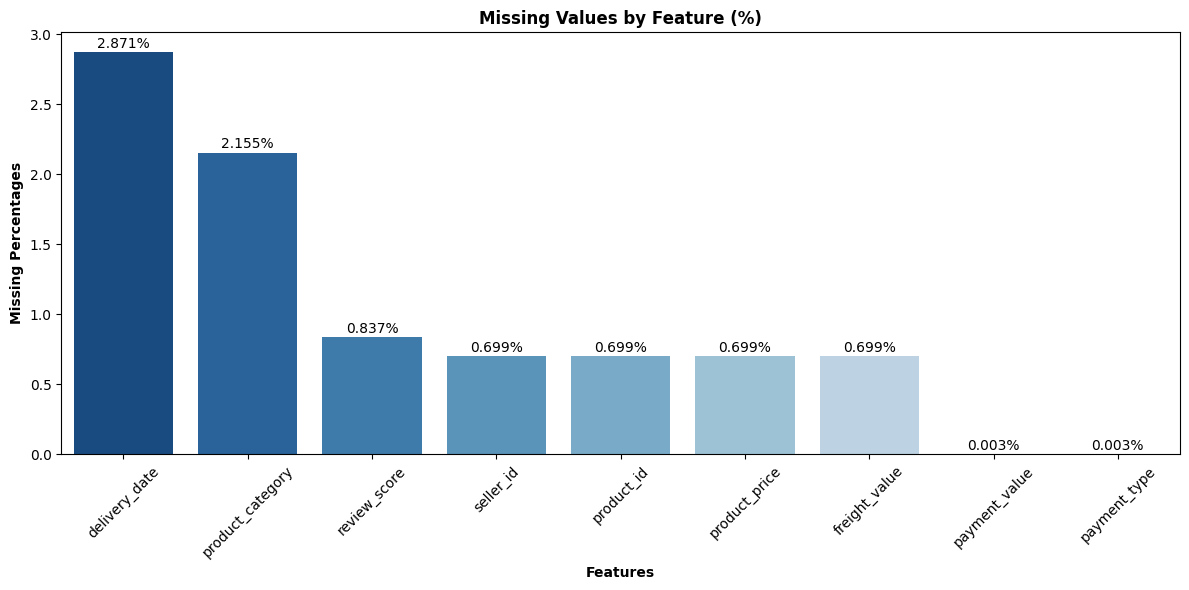

In [26]:
# Visualize the Percentage of Missing Values by Features
plt.figure(figsize=(12,6))
sns.barplot(
    data=missing_summary,
    x=missing_summary.index,
    y="missing_percentages",
    hue=missing_summary.index,
    palette="Blues_r",
    legend=False
)
plt.title("Missing Values by Feature (%)", weight="bold")
plt.xlabel("Features", weight="bold")
plt.ylabel("Missing Percentages", weight="bold")
plt.xticks(rotation=45)
for i, v in enumerate(missing_summary["missing_percentages"]):
    plt.text(i, v + 0.03, f"{v:.3f}%", ha="center")
plt.tight_layout()
plt.show()

#### Key Observations:
The integrated dataset was cleaned for dta qualiy before the analysis, to ensure reliable results. The task for this stage was to identify missing values, deal with incomplete data, remove duplicated records and prepare in such a way as to analyse the data in this stage. The percentage of missing values was not high, so an appropriate method of clean-up was used, preserving th majority of the information.

Most of the features have less tha 3% missing data as demonstrated in the missing value analysis; the dataset is fairly complete.

In [27]:
# Display Missing data of Delivery
df[df["delivery_date"].isnull()].sample(5)

,order_id,order_status,order_date,delivery_date,estimated_delivery_date,customer_unique_id,customer_city,customer_state,product_id,product_category,seller_id,product_price,freight_value,payment_value,payment_type,review_score
62809,053245dc8f6f668c40923c3aedcd384e,shipped,2017-06-06 19:09:17,NaN,2017-07-17 00:00:00,830e6d22ba593f1679ea0692f0357604,ituiutaba,MG,a8eed0daf7e2db5e074d2d4f65046946,sports_leisure,adcf50477d6a1f5d91bb9d54c4903cb5,17.55,24.04,110.90,credit_card,3.0
87430,dd8d541616639212eb325bc7d015350b,shipped,2018-05-16 13:03:16,NaN,2018-06-25 00:00:00,7bfb4300feb2a2ad6bcfba76fca42493,rio de janeiro,RJ,3dd2a17168ec895c781a9191c1e95ad7,computers_accessories,de722cd6dad950a92b7d4f82673f8833,149.90,11.18,161.08,credit_card,NaN
17815,10271ddf4e66d7ebde86598c2447761d,invoiced,2017-01-30 12:15:14,NaN,2017-03-17 00:00:00,712f57b0313fdcf9ebbae22e13082da8,contagem,MG,d585c50d622ff40b4d69959caa42a5a3,health_beauty,64b87978a11c1ea7501a89eabe8c2c1a,69.99,18.00,87.99,credit_card,3.0
26450,b210c676cae65f95f7e08a49d195e1a1,unavailable,2017-07-21 14:40:21,NaN,2017-08-16 00:00:00,ec9c7ebb2a345ccd42c46b94ecb4d319,araujos,MG,NaN,NaN,NaN,NaN,NaN,85.14,credit_card,1.0
89686,f434066a90c729686966ab151fa4c7ec,unavailable,2018-01-19 01:08:20,NaN,2018-02-15 00:00:00,693c64859208c1cc7bb6f65c73836841,maringa,PR,NaN,NaN,NaN,NaN,NaN,55.60,credit_card,1.0


In [28]:
# Create a binary feature indicating that the order is successfully delivered
df["is_delivered"] = df["delivery_date"].notna()

In [29]:
# Replacing missing values with "Unknown"
df["product_category"] = df["product_category"].fillna("Unknown")

In [30]:
# Display the missing data of review score
df[df["review_score"].isna()].sample(5)

,order_id,order_status,order_date,delivery_date,estimated_delivery_date,customer_unique_id,customer_city,customer_state,product_id,product_category,seller_id,product_price,freight_value,payment_value,payment_type,review_score,is_delivered
21044,2cce76800d1714350808d3b4c0a48d58,delivered,2017-05-20 16:37:21,2017-06-07 07:26:47,2017-06-14 00:00:00,2ab86468156082e06168e255e42df321,florianopolis,SC,8fd4a0aecf57598dcdc75d1520069acf,perfumery,fe2032dab1a61af8794248c8196565c9,179.0,15.00,194.00,credit_card,NaN,True
4336,f8c9df743a18aeeedd550486dbe39689,delivered,2018-06-07 17:52:27,2018-06-19 15:58:51,2018-07-11 00:00:00,f145d50379275ab9931636f83b0102eb,salvador,BA,928e52a9ad53a294fdcc91bcf59d1751,housewares,955fee9216a65b617aa5c0531780ce60,130.0,20.64,61.48,credit_card,NaN,True
97701,5f5a937b8e63ac95df2db115354de971,delivered,2017-12-23 14:11:57,2018-02-08 18:53:28,2018-01-30 00:00:00,db5b5f882178662b38134fb75c2e22ec,porto alegre,RS,a04087ab6a96ffa041f8a2701a72b616,computers,53243585a1d6dc2643021fd1853d8905,599.0,82.42,681.42,boleto,NaN,True
112585,ab14fdcfbe524636d65ee38360e22ce8,delivered,2017-08-23 09:22:34,2017-09-02 12:13:03,2017-09-21 00:00:00,698e1cf81d01a3d389d96145f7fa6df8,goiania,GO,9571759451b1d780ee7c15012ea109d4,auto,ce27a3cc3c8cc1ea79d11e561e9bebb6,98.7,14.44,2262.80,credit_card,NaN,True
63619,8a7db04d95da0710527731c9945b4d34,delivered,2017-11-28 16:27:19,2017-12-15 09:37:01,2017-12-18 00:00:00,c0d3fe5df1e0d9f039d407115d15b0a0,primavera,SP,056d012d264624accb7f73d31caee034,bed_bath_table,8160255418d5aaa7dbdc9f4c64ebda44,116.9,13.16,260.12,credit_card,NaN,True


In [31]:
# Create a binary feature indicating that the customer is reviewed
df["has_review"] = df["review_score"].notna()

In [32]:
# Check order status data with mising product id
df[df["product_id"].isna()]["order_status"].value_counts()

,count
order_status,
unavailable,645
canceled,180
created,5
invoiced,2
shipped,1


In [33]:
# Remove missing payment values
df = df.dropna(subset=["payment_value", "payment_type"])

### 4.2 Duplicate Value Analysis

In [34]:
# Check Duplicate Values
duplicates = df.duplicated().sum()
print(f"Total No. of Duplicate Values {duplicates}")

if duplicates > 0:
  df = df.drop_duplicates()
  print(f"\nRemoved {duplicates} duplicate rows!")
else:
  print("\nNo Duplicate Values!")


print("\nNo. of Rows After Cleaning    : ", df.shape[0])
print("No. of Column After Cleaning  : ", df.shape[1])

Total No. of Duplicate Values 11694

Removed 11694 duplicate rows!

No. of Rows After Cleaning    :  107446
No. of Column After Cleaning  :  18


#### Overall Cleaning Summary:
* Recognised missing data and worked out percentages.
* If a product category was not specific, it was filled with thw "Unknown" option.
* Made a delivery_date based is_delivered indicator.
* Kept out of the list missing review scores that are real life -business scenarios.
* Deleted rows that were missing payments.
* Removed 11,694 duplicate records, to generate final analytical dataset.
* The cleaned dataset is now consistent, reliable and available for exploratory data analysis and busienss intelligence reporting.

# 5. Feature Analysis

### 5.1 Featues Inspection

In [35]:
# Analyze each features with datatypes and unique values
for col in df.columns:
  unique = df[col].unique()
  print("Feature: ", col)
  print("Data Type: ", df[col].dtypes)
  print("\nUnique Values: ", unique)
  print("No. of Unique Values: ", len(unique))
  print("-"* 100)

Feature:  order_id
Data Type:  object

Unique Values:  ['e481f51cbdc54678b7cc49136f2d6af7' '53cdb2fc8bc7dce0b6741e2150273451'
 '47770eb9100c2d0c44946d9cf07ec65d' ... '83c1379a015df1e13d02aae0204711ab'
 '11c177c8e97725db2631073c19f07b62' '66dea50a8b16d9b4dee7af250b4be1a5']
No. of Unique Values:  99440
----------------------------------------------------------------------------------------------------
Feature:  order_status
Data Type:  object

Unique Values:  ['delivered' 'invoiced' 'shipped' 'processing' 'unavailable' 'canceled'
 'created' 'approved']
No. of Unique Values:  8
----------------------------------------------------------------------------------------------------
Feature:  order_date
Data Type:  object

Unique Values:  ['2017-10-02 10:56:33' '2018-07-24 20:41:37' '2018-08-08 08:38:49' ...
 '2017-08-27 14:46:43' '2018-01-08 21:28:27' '2018-03-08 20:57:30']
No. of Unique Values:  98874
--------------------------------------------------------------------------------------------

In [36]:
# Convert date columns to datetime format
df["order_date"] = pd.to_datetime(
    df["order_date"],
    errors="coerce"
)

df["delivery_date"] = pd.to_datetime(
    df["delivery_date"],
    errors="coerce"
)

df["estimated_delivery_date"] = pd.to_datetime(
    df["estimated_delivery_date"],
    errors="coerce"
)

#### Observations:
Once the dataset was cleaned, each feature was examied to determine the data type, possible unique values, and prepare data for exploratory analysis. Date columns were also added using the datetime data type to enable time-based analysis like monthly trends and delivery performance.
* This dataset includes 18 business features that include orders, customers, products, payments, logistics, and customer reviews.
* The categorical features includes order status, customer city, customer state, product category, seller id, and payment type.
* Other numerical charecteristics are product price, frright value, payment value ad review score.
* All of the date variables(order date, delivery date, and estimated delivery date) was converted to the daetime data type to allow chronological analysis and calculation of deliveries.

In [37]:
# Split Data into Numerical and Categorical Columns
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

### 5.2 Correlation Analysis

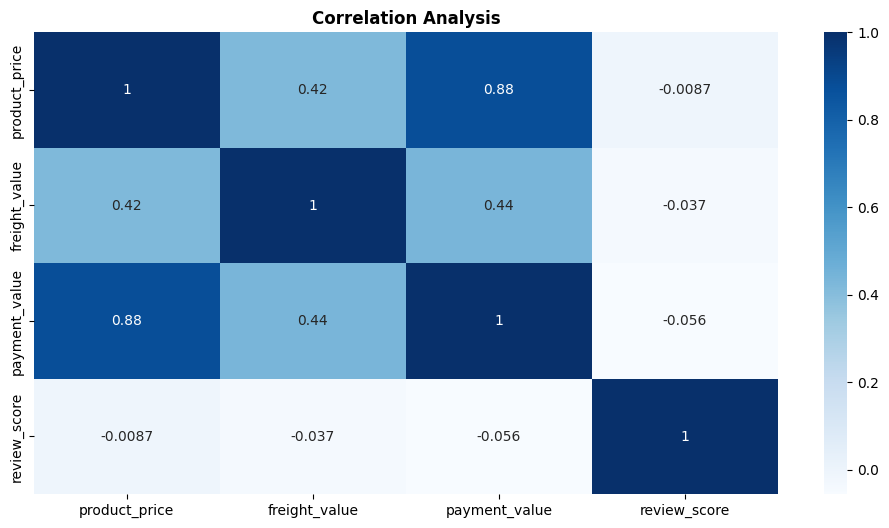

In [38]:
# Correlation Matrix
df_corr = df[num_cols].corr()

plt.figure(figsize=(12,6))
sns.heatmap(df_corr, annot=True, cmap="Blues")
plt.title("Correlation Analysis", weight="bold")
plt.show()

The relationship between numerical features (product price, freight value, and review score) were analyzed by correlation analysis.
### Key Observations:
* Product price and payment value have a strong possitive correlation (0.88).
* There is moderate correlation between freight value and product price, payment value.
* The financial variables are virtually uncorrelated with Review score.

### 5.3 Statistical Analyisis

In [39]:
# Descriptive Statistics
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
product_price,106634.0,124.428688,189.624471,0.85,40.00,78.000,139.0000,6735.00
freight_value,106634.0,20.146071,15.909555,0.00,13.15,16.350,21.2475,409.68
payment_value,107446.0,158.309276,220.173991,0.00,58.27,102.865,176.8175,13664.08
review_score,106599.0,4.055404,1.370380,1.00,4.00,5.000,5.0000,5.00


Descriptive statistics simply are used to summarize the distribution of the numerical charecteristics of the data.
#### Key Observations:
* Average product price: 124.43
* Average payment value: 158.31
* Average payment value: 20.15
* Average review score: 4.06/5

The statistics show that majority of customers rate the product positively, and the amount spent by customers varies from order to order.

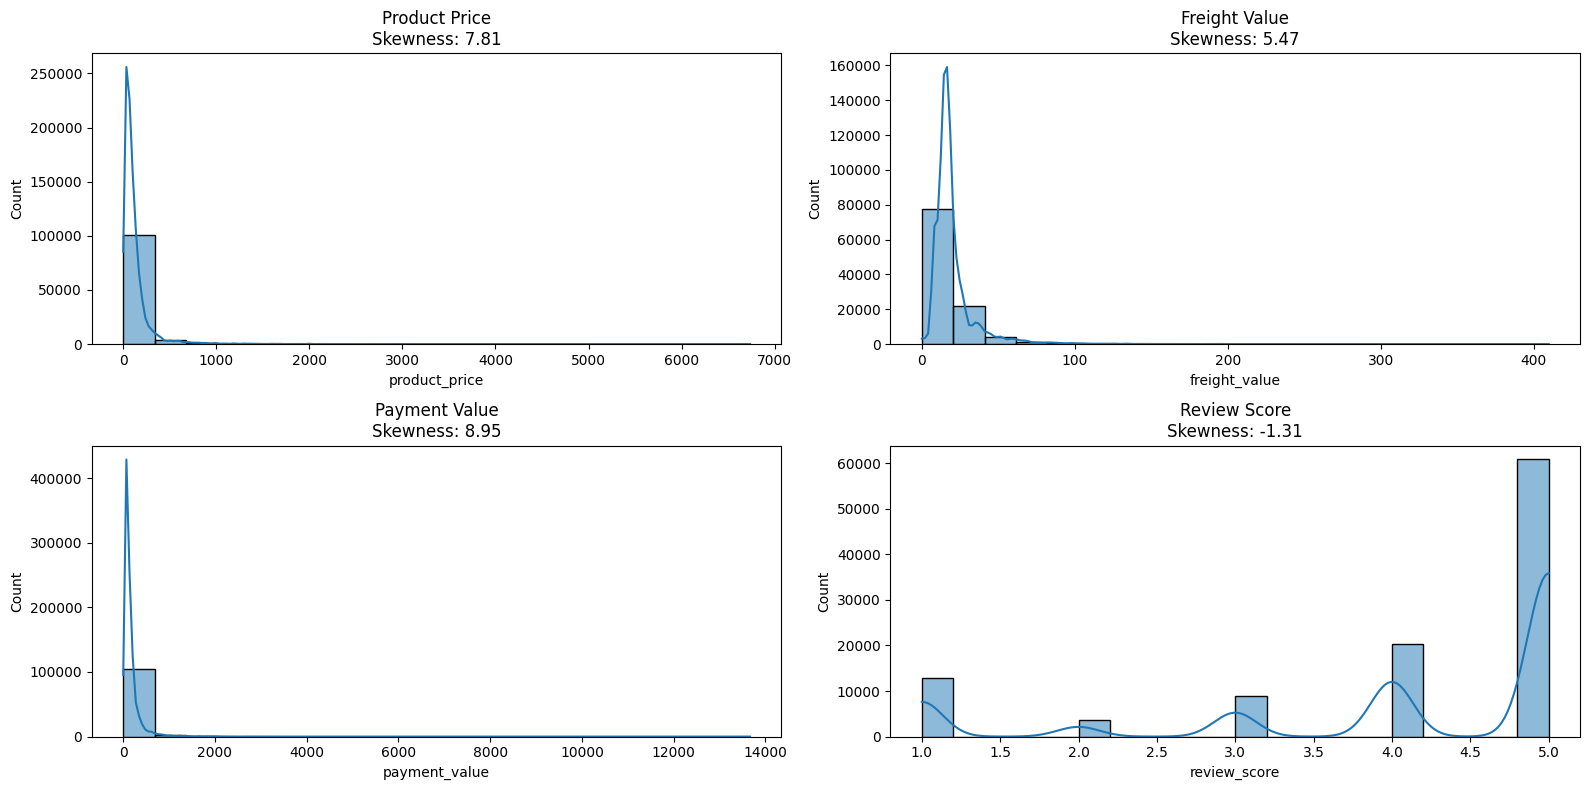

In [40]:
# Visualize the distribution and skewness
plt.figure(figsize=(16,8))
for i, col in enumerate (num_cols):
  plt.subplot(2,2,i+1)
  sns.histplot(df[col], kde=True, bins=20)
  plt.title(f"{col.replace("_"," ").title()}\nSkewness: {df[col].skew():.2f}")

plt.tight_layout()
plt.show()

In [41]:
# Display all categorical columns
df[cat_cols]

,order_id,order_status,customer_unique_id,customer_city,customer_state,product_id,product_category,seller_id,payment_type
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,87285b34884572647811a353c7ac498a,housewares,3504c0cb71d7fa48d967e0e4c94d59d9,credit_card
1,e481f51cbdc54678b7cc49136f2d6af7,delivered,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,87285b34884572647811a353c7ac498a,housewares,3504c0cb71d7fa48d967e0e4c94d59d9,voucher
2,e481f51cbdc54678b7cc49136f2d6af7,delivered,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,87285b34884572647811a353c7ac498a,housewares,3504c0cb71d7fa48d967e0e4c94d59d9,voucher
3,53cdb2fc8bc7dce0b6741e2150273451,delivered,af07308b275d755c9edb36a90c618231,barreiras,BA,595fac2a385ac33a80bd5114aec74eb8,perfumery,289cdb325fb7e7f891c38608bf9e0962,boleto
4,47770eb9100c2d0c44946d9cf07ec65d,delivered,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,aa4383b373c6aca5d8797843e5594415,auto,4869f7a5dfa277a7dca6462dcf3b52b2,credit_card
...,...,...,...,...,...,...,...,...,...
119137,9c5dedf39a927c1b2549525ed64a053c,delivered,6359f309b166b0196dbf7ad2ac62bb5a,sao jose dos campos,SP,ac35486adb7b02598c182c2ff2e05254,health_beauty,e24fc9fcd865784fb25705606fe3dfe7,credit_card
119138,63943bddc261676b46f01ca7ac2f7bd8,delivered,da62f9e57a76d978d02ab5362c509660,praia grande,SP,f1d4ce8c6dd66c47bbaa8c6781c2a923,baby,1f9ab4708f3056ede07124aad39a2554,credit_card
119139,83c1379a015df1e13d02aae0204711ab,delivered,737520a9aad80b3fbbdad19b66b37b30,nova vicosa,BA,b80910977a37536adeddd63663f916ad,home_appliances_2,d50d79cb34e38265a8649c383dcffd48,credit_card
119140,11c177c8e97725db2631073c19f07b62,delivered,5097a5312c8b157bb7be58ae360ef43c,japuiba,RJ,d1c427060a0f73f6b889a5c7c61f2ac4,computers_accessories,a1043bafd471dff536d0c462352beb48,credit_card


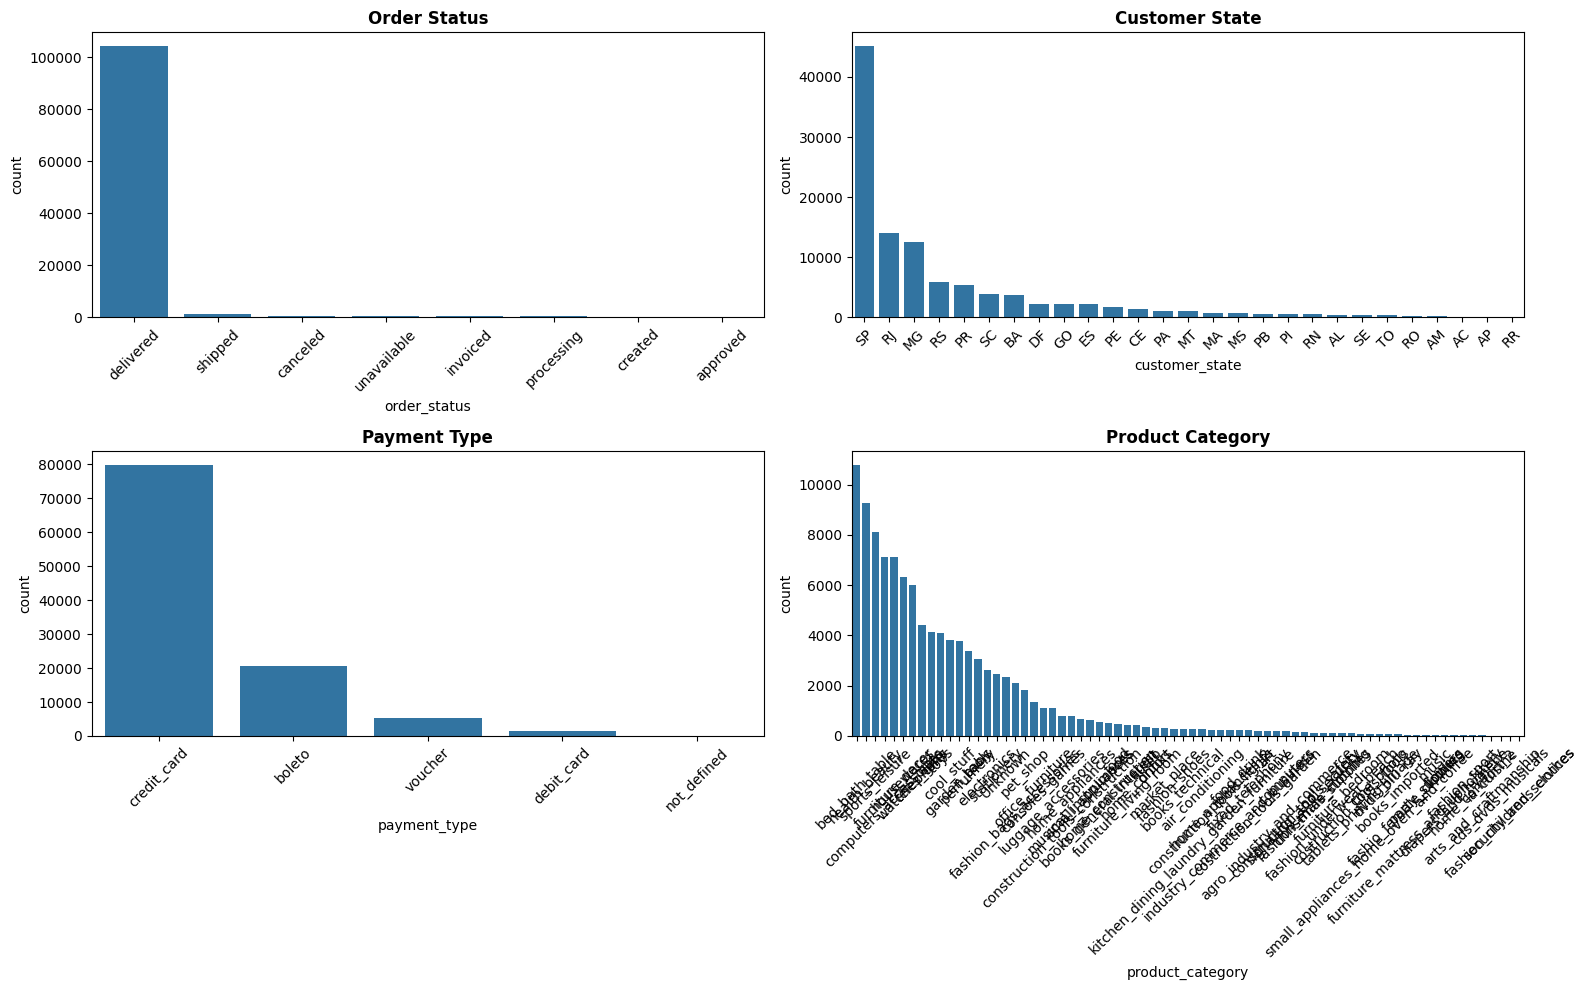

In [42]:
# Visualize the data distribution in categorical columns
viz_cat_cols = [
    "order_status",
    "customer_state",
    "payment_type",
    "product_category"

]
plt.figure(figsize=(16,10))

for i, col in enumerate(viz_cat_cols):
    plt.subplot(2,2,i+1)
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(col.replace("_"," ").title(), weight="bold")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

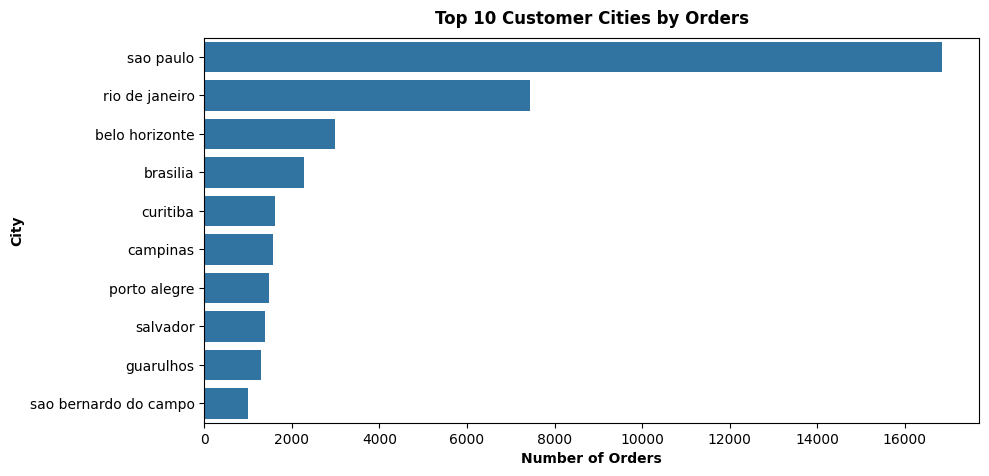

In [43]:
# Identify the Top10 Cities by No. of Orders
top10_city = df["customer_city"].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top10_city.values, y=top10_city.index)
plt.title("Top 10 Customer Cities by Orders", weight="bold", pad=10)
plt.xlabel("Number of Orders", weight="bold")
plt.ylabel("City", weight="bold")
plt.show()

# 6. Feature Engineering

In [44]:
# Display first 10 data
df.head(10)

,order_id,order_status,order_date,delivery_date,estimated_delivery_date,customer_unique_id,customer_city,customer_state,product_id,product_category,seller_id,product_price,freight_value,payment_value,payment_type,review_score,is_delivered,has_review
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,87285b34884572647811a353c7ac498a,housewares,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,18.12,credit_card,4.0,True,True
1,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,87285b34884572647811a353c7ac498a,housewares,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,2.00,voucher,4.0,True,True
2,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,87285b34884572647811a353c7ac498a,housewares,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,18.59,voucher,4.0,True,True
3,53cdb2fc8bc7dce0b6741e2150273451,delivered,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,barreiras,BA,595fac2a385ac33a80bd5114aec74eb8,perfumery,289cdb325fb7e7f891c38608bf9e0962,118.70,22.76,141.46,boleto,4.0,True,True
4,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,aa4383b373c6aca5d8797843e5594415,auto,4869f7a5dfa277a7dca6462dcf3b52b2,159.90,19.22,179.12,credit_card,5.0,True,True
5,949d5b44dbf5de918fe9c16f97b45f8a,delivered,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,d0b61bfb1de832b15ba9d266ca96e5b0,pet_shop,66922902710d126a0e7d26b0e3805106,45.00,27.20,72.20,credit_card,5.0,True,True
6,ad21c59c0840e6cb83a9ceb5573f8159,delivered,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,65266b2da20d04dbe00c5c2d3bb7859e,stationery,2c9e548be18521d1c43cde1c582c6de8,19.90,8.72,28.62,credit_card,5.0,True,True
7,a4591c265e18cb1dcee52889e2d8acc3,delivered,2017-07-09 21:57:05,2017-07-26 10:57:55,2017-08-01,80bb27c7c16e8f973207a5086ab329e2,congonhinhas,PR,060cb19345d90064d1015407193c233d,auto,8581055ce74af1daba164fdbd55a40de,147.90,27.36,175.26,credit_card,4.0,True,True
8,136cce7faa42fdb2cefd53fdc79a6098,invoiced,2017-04-11 12:22:08,NaT,2017-05-09,36edbb3fb164b1f16485364b6fb04c73,santa rosa,RS,a1804276d9941ac0733cfd409f5206eb,Unknown,dc8798cbf453b7e0f98745e396cc5616,49.90,16.05,65.95,credit_card,2.0,False,True
9,6514b8ad8028c9f2cc2374ded245783f,delivered,2017-05-16 13:10:30,2017-05-26 12:55:51,2017-06-07,932afa1e708222e5821dac9cd5db4cae,nilopolis,RJ,4520766ec412348b8d4caa5e8a18c464,auto,16090f2ca825584b5a147ab24aa30c86,59.99,15.17,75.16,credit_card,5.0,True,True


### 6.1 Extract Data from Order Year
Transform order_date column into new features that will enable trend and seasonality analysis. These features will help in the analysis of sales patterns month by month, day of the week , and hour.

In [45]:
#. Extract Year from Order Year
df["order_year"] = df["order_date"].dt.year
df[["order_date", "order_year"]].sample(5)

,order_date,order_year
88042,2017-08-15 12:54:48,2017
45536,2017-12-21 23:30:00,2017
54164,2017-11-24 12:35:09,2017
41470,2018-07-30 20:23:34,2018
15377,2017-03-13 14:17:40,2017


In [46]:
# Extract Month from Order Year
df["order_month_name"] = df["order_date"].dt.month_name()
df[["order_date", "order_month_name"]].sample(5)

,order_date,order_month_name
44616,2017-03-21 17:34:37,March
111826,2018-05-30 13:41:58,May
21043,2018-07-04 17:42:51,July
4875,2018-05-02 13:54:46,May
87120,2018-02-11 19:42:18,February


In [47]:
# Extract Day from Order Year
df["order_day_name"] = df["order_date"].dt.day_name()
df[["order_date", "order_day_name"]].sample(5)

,order_date,order_day_name
43933,2017-06-05 16:34:47,Monday
16319,2018-05-04 19:16:41,Friday
79071,2018-01-11 17:07:57,Thursday
9608,2018-03-15 14:16:20,Thursday
7164,2018-02-18 19:21:55,Sunday


In [48]:
# Extract Hour from Order Year
df["order_hour"] = df["order_date"].dt.hour
df[["order_date", "order_hour"]].sample(5)

,order_date,order_hour
107588,2017-08-13 22:25:01,22
16651,2018-08-02 12:06:09,12
97327,2017-06-21 09:18:25,9
29196,2017-11-27 16:02:39,16
104888,2018-08-03 08:40:58,8


# 7. Exploratory Data Analysis (EDA)

## Q1. Which product categories generate the highest revenue, and which should receive greater investment?

### Business Objective:
Determine which product categories are most profitable for product investment, inventory planning and marketing.

In [49]:
# Find the total revenue by each order
revenue = df.groupby("order_id")["product_price"].sum().sort_values(ascending=False)
revenue

,product_price
order_id,
fa65dad1b0e818e3ccc5cb0e39231352,9813.75
f489949dbe23cf9313deb342913ece0c,8160.12
80dfedb6d17bf23539beeef3c768f4d7,7998.00
9de73f3e6157169ad6c32b9f313c7dcb,7798.00
0812eb902a67711a1cb742b3cdaa65ae,6735.00
...,...
9380c59012c11f49c549ef8dffef1367,0.00
92fca7ed7b7df4695007bd7f227e3333,0.00
93274b931b5771bd02154c9b716168ba,0.00


In [50]:
# each order recorded as unique id
df["revenue"] = df["product_price"]

In [51]:
# Calculate revenue by product category
category_revenue = (
    df[df["product_category"] != "Unknown"]
    .groupby("product_category")["revenue"]
    .sum()
    .sort_values(ascending=False))
category_revenue

,revenue
product_category,
health_beauty,1242200.80
watches_gifts,1233602.80
bed_bath_table,1016309.48
sports_leisure,959778.20
computers_accessories,836343.31
...,...
flowers,962.94
home_comfort_2,695.77
cds_dvds_musicals,640.00


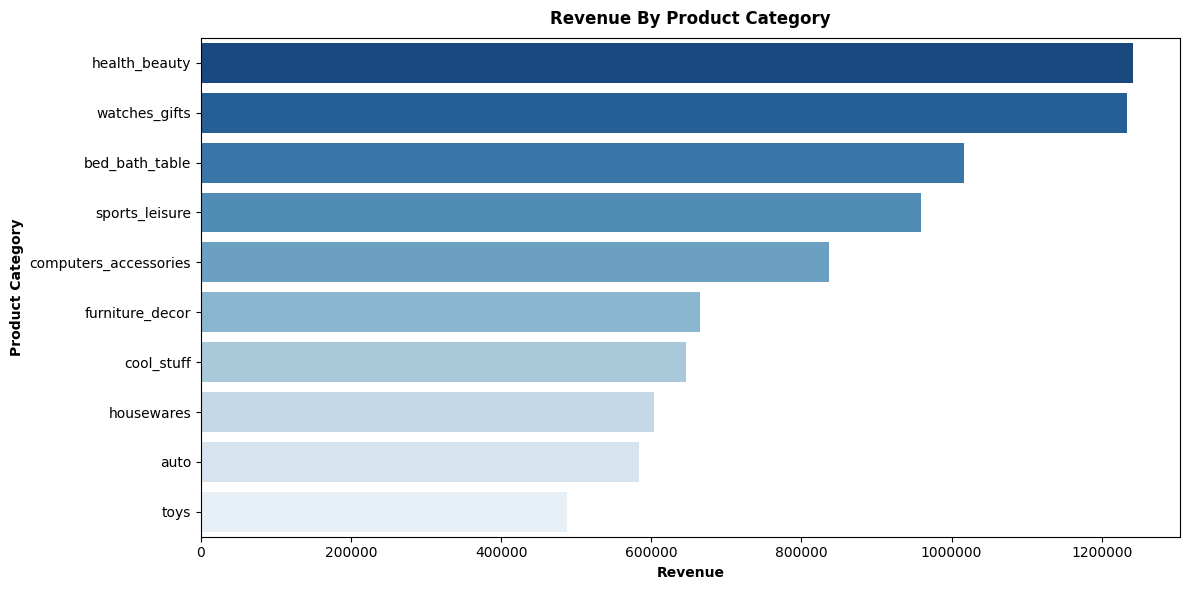

In [52]:
# Visualize the top 10 product category by total revenue
plt.figure(figsize=(12,6))
sns.barplot(
    x=category_revenue.head(10).values,
    y=category_revenue.head(10).index,
    hue=category_revenue.head(10).index,
    palette="Blues_r",
)
plt.title("Revenue By Product Category", weight="bold", pad=10)
plt.xlabel("Revenue", weight="bold")
plt.ylabel("Product Category", weight="bold")
plt.ticklabel_format(style="plain", axis="x")
plt.tight_layout()
plt.show()

### Key Findings:
* Health & Beauty earned the most money (1,242,200.80)
* Watches & Gidt was 2nd with 123602.80 in revenue.
* Bed Bath Table, Sports & Leisure and Computers & Accessories are also good revenue producers.
* Flowers, Home Comfort 2 and Security & Services are the lowest revenue items and could be a strategic option to review.
### Business Insight:
The firm needs to focus on high performing categories for increased stock and promotions, and on low revenue categories to enhance profitability or product selection.

## Q2. Which customer states generate the highest revenue, and where should the company prioritize regional expansion?

### Business Objective
* Which state contribute the most revenue?
* Which regions are the strongest markets?
* Where should marketing and logistics investment be prioritized?

In [53]:
# Calculate total revenue by customer state
states_revenue = (
    df.groupby("customer_state")["revenue"]
    .sum()
    .sort_values(ascending=False)
)
states_revenue.head(10)

,revenue
customer_state,
SP,5077482.13
RJ,1787333.24
MG,1541808.98
RS,735576.76
PR,654499.27
SC,501756.46
BA,497318.06
DF,298352.18
GO,283007.42


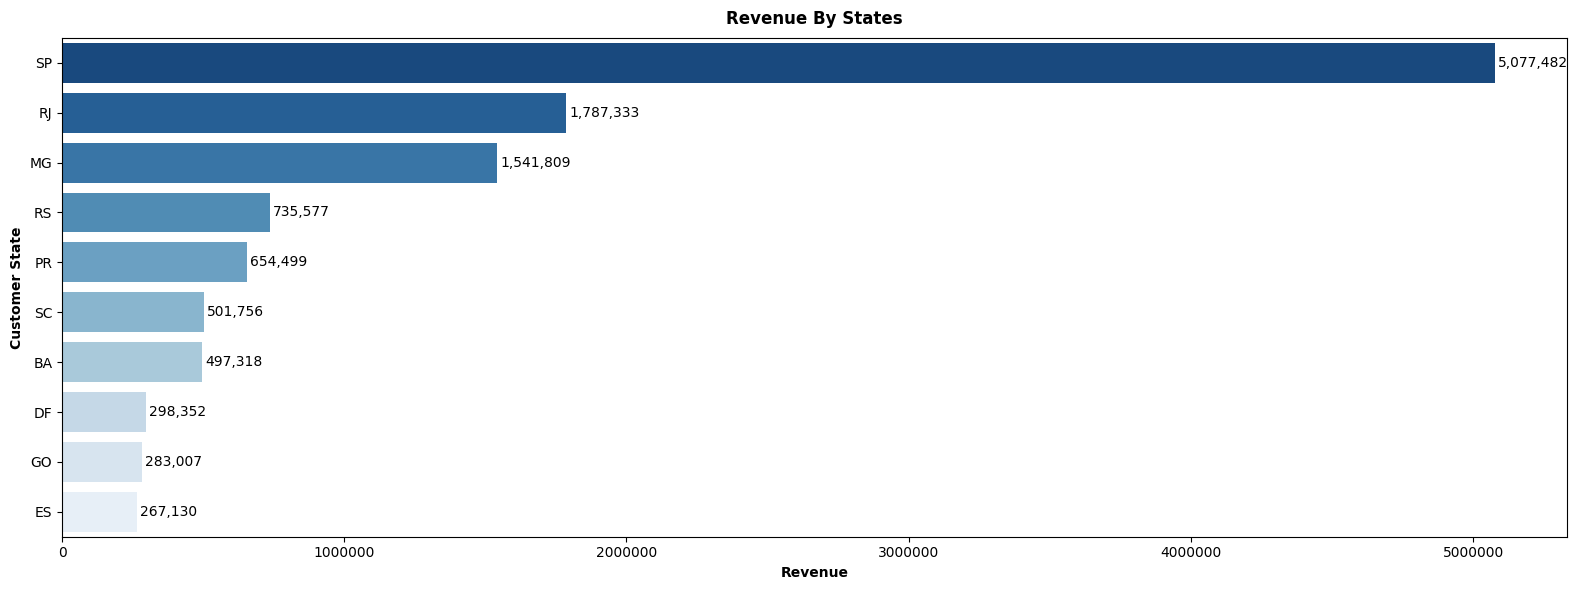

In [54]:
# visualize top 10 states by total revenue
plt.figure(figsize=(16,6))
ax = sns.barplot(
    x=states_revenue.head(10).values,
    y=states_revenue.head(10).index,
    hue=states_revenue.head(10).index,
    palette="Blues_r"
)

for i, v in enumerate(states_revenue.head(10).values):
  ax.text(v + 10000, i, f"{v:,.0f}", va="center")

plt.title("Revenue By States", weight="bold", pad=10)
plt.xlabel("Revenue", weight="bold")
plt.ylabel("Customer State", weight="bold")
plt.ticklabel_format(style="plain", axis="x")
plt.tight_layout()
plt.show()

In [55]:
# Find the lowest revenue states
lowest_states_revenue = (
    df.groupby("customer_state")["revenue"]
    .sum()
    .sort_values(ascending=True)
)
lowest_states_revenue.head(10)

,revenue
customer_state,
RR,6958.52
AP,12151.27
AC,16157.35
AM,21539.88
RO,45841.36
TO,50149.77
SE,57165.06
AL,79896.40
PI,85614.82


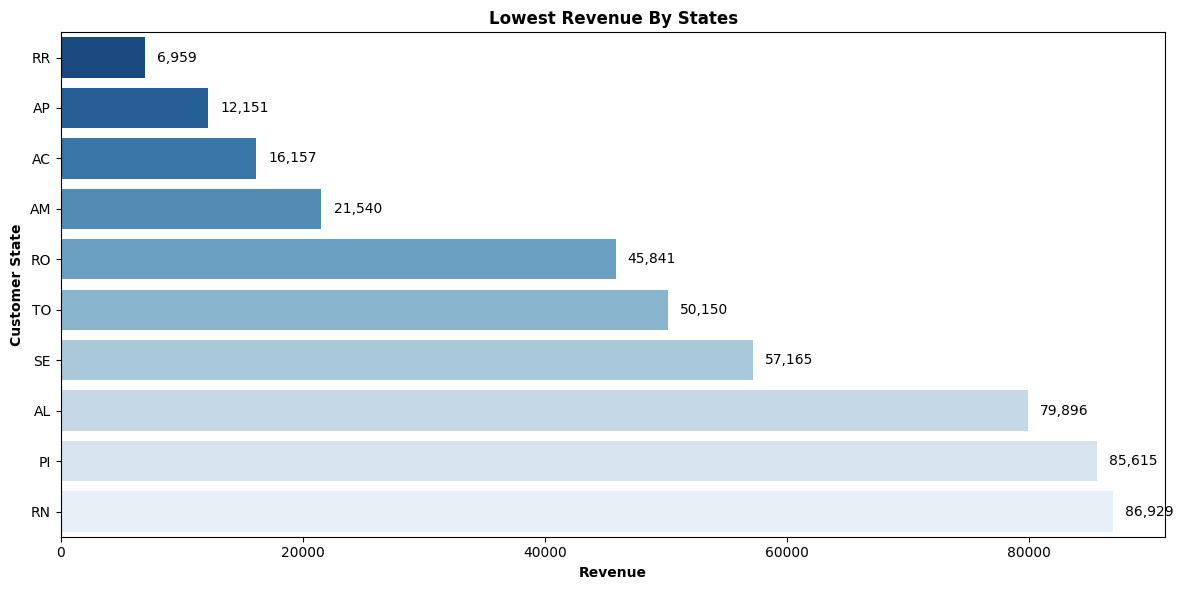

In [56]:
# Visualize the 10 lowest states
plt.figure(figsize=(12,6))
ax = sns.barplot(
    x=lowest_states_revenue.head(10).values,
    y=lowest_states_revenue.head(10).index,
    hue=lowest_states_revenue.head(10).index,
    palette="Blues_r"
)
for i, v in enumerate(lowest_states_revenue.head(10).values):
  ax.text(v + 1000, i, f"{v:,.0f}", va="center")

plt.title("Lowest Revenue By States", weight="bold")
plt.xlabel("Revenue", weight="bold")
plt.ylabel("Customer State", weight="bold")
plt.ticklabel_format(style="plain", axis="x")
plt.tight_layout()
plt.show()

### Key Findings:
 Highest Revenue States
* SP had the highest revenue of 5,077,482.
* RJ and MG ranked second and third with 1,787,333 and 1,541,809, respectively.
* The three states generate significant company profits.

Lowest Revenue States:
* RR has the fewest sales (6,959).
* The markets were also less demanding for AP and AC due to the fact that they brought in lower revenues.
* Other low performing states are: AM, RO, TO.
### Business Insight:
The compny should focus its investments and growth in SP, RJ, and MG where the demand is the highest. Before scaling up, low-revenue states might need some special marketing campaigns or logistics plans.

## Q3. How does customer spending vary across different payment methods?
### Business Objective:
Compare customer's purchases by payment methods to uncover payment behaviour and the payment methods of customers wo are buying more expensive items.

In [57]:
# Calculate average customer spending by payment type
customer_spending = (
    df.groupby("payment_type")["payment_value"]
    .mean()
    .sort_values(ascending=False)
)
customer_spending

,payment_value
payment_type,
credit_card,166.671711
boleto,149.541196
debit_card,147.995685
voucher,70.920967
not_defined,0.000000


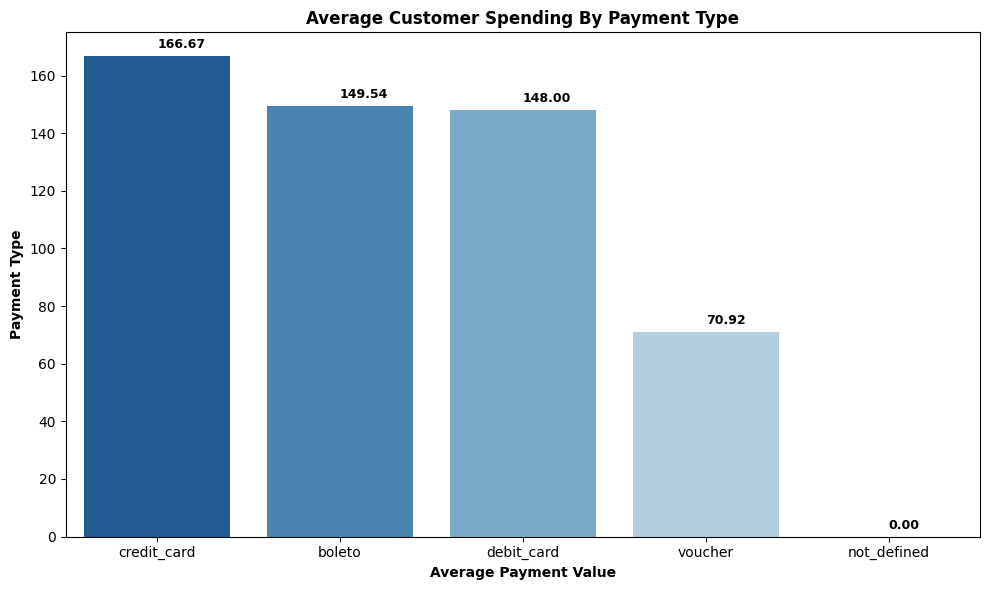

In [58]:
# Visualize Average Spending by Payment Type
plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=customer_spending.index,
    y=customer_spending.values,
    hue=customer_spending.index,
    palette="Blues_r"
)
for i, v in enumerate(customer_spending.values):
  ax.text(i, v+4, f"{v:.2f}", va="center", weight="bold", fontsize=9)

plt.title("Average Customer Spending By Payment Type", weight="bold")
plt.xlabel("Average Payment Value", weight="bold")
plt.ylabel("Payment Type", weight="bold")
plt.tight_layout()
plt.show()

### Key Finding:
* Mean spending per customer of the Credit Card was greatest (166.67).
* Average spending of Boleto and Debit Card was similar at 149.54 and 148.00.
* The average spending of voucher payments was the lowest (70.92)

### Business Insight:
Credit Card are linked to higher-priced items, and thus the most useful form of payment for revenue generation. Lower value transactions are usually paid by voucher.

## Q4. Does delayed delivery reduce customer satisfaction?
### Business Objectives:
Compare average review ratings based on delivery status to determine if delivery performance impacts on customer satisfaction.

In [59]:
# Delivery delay in days
df["delivery_delay"] = (df["delivery_date"] - df["estimated_delivery_date"]).dt.days
df[["order_status", "order_date", "delivery_date", "estimated_delivery_date", "delivery_delay", "review_score"]].sample(10)

,order_status,order_date,delivery_date,estimated_delivery_date,delivery_delay,review_score
90188,delivered,2018-07-01 22:16:18,2018-07-06 18:08:35,2018-07-26,-20.0,5.0
29393,delivered,2018-01-31 16:57:52,2018-02-14 22:36:31,2018-02-26,-12.0,5.0
52880,delivered,2018-04-08 06:42:55,2018-04-14 17:42:12,2018-05-10,-26.0,5.0
118058,delivered,2017-11-24 23:07:12,2017-12-12 19:45:03,2017-12-19,-7.0,3.0
113765,delivered,2017-03-10 19:32:26,2017-03-27 18:38:20,2017-04-05,-9.0,5.0
107834,delivered,2017-08-13 15:15:27,2017-08-15 16:36:07,2017-08-25,-10.0,5.0
60982,delivered,2018-08-20 21:12:57,2018-08-24 20:14:49,2018-08-23,1.0,5.0
41703,delivered,2017-05-11 14:37:06,2017-05-26 10:37:57,2017-06-05,-10.0,5.0
11079,delivered,2018-03-13 18:20:46,2018-03-22 13:42:36,2018-04-11,-20.0,3.0
13114,delivered,2017-06-29 17:19:24,2017-07-13 21:07:52,2017-07-26,-13.0,4.0


The time gap between the actual and estimated delivery date was used to calculate the delivery delay. This was then used to categorize orders as Early, On Time, and Late.
* Positive = Late
* Negative = Early
* 0        = On Time

In [60]:
# Display the data of orders that delivered on time
df_on_time = df[df["delivery_delay"]==0]
df_on_time[["order_status", "order_date", "delivery_date", "estimated_delivery_date", "delivery_delay", "review_score"]].sample(20)

,order_status,order_date,delivery_date,estimated_delivery_date,delivery_delay,review_score
43401,delivered,2017-02-02 09:33:28,2017-03-01 09:35:30,2017-03-01,0.0,3.0
104359,delivered,2018-03-02 09:34:05,2018-04-05 21:33:21,2018-04-05,0.0,1.0
8374,delivered,2018-02-05 16:41:52,2018-03-02 22:27:27,2018-03-02,0.0,4.0
108558,delivered,2018-02-25 12:15:25,2018-03-16 23:48:13,2018-03-16,0.0,5.0
92621,delivered,2017-11-12 23:19:39,2017-12-01 20:03:17,2017-12-01,0.0,3.0
41265,delivered,2018-03-19 20:17:12,2018-04-20 16:25:25,2018-04-20,0.0,3.0
108231,delivered,2018-03-08 19:20:57,2018-03-26 22:11:29,2018-03-26,0.0,3.0
26122,delivered,2018-08-08 08:46:02,2018-08-13 16:20:52,2018-08-13,0.0,4.0
89332,delivered,2018-05-14 16:59:30,2018-06-04 17:33:01,2018-06-04,0.0,5.0
91293,delivered,2018-03-05 16:13:08,2018-04-03 17:52:20,2018-04-03,0.0,5.0


In [61]:
# Delivered orders with delivery delay and review score
df_delivered = df[df["order_status"]=="delivered"]
df_delivered[["order_status", "order_date", "delivery_date", "estimated_delivery_date", "delivery_delay", "review_score"]].sample(10)

,order_status,order_date,delivery_date,estimated_delivery_date,delivery_delay,review_score
106981,delivered,2017-09-12 20:45:20,2017-09-18 14:03:21,2017-09-28,-10.0,1.0
32322,delivered,2017-07-07 14:35:52,2017-07-17 15:51:25,2017-07-27,-10.0,5.0
50635,delivered,2018-02-21 20:53:04,2018-03-09 21:24:42,2018-03-16,-7.0,5.0
101124,delivered,2018-06-21 12:54:27,2018-07-11 19:26:35,2018-07-25,-14.0,5.0
117508,delivered,2017-09-22 19:54:54,2017-10-03 19:28:08,2017-10-18,-15.0,5.0
105113,delivered,2018-02-03 12:46:10,2018-02-22 18:49:56,2018-03-01,-7.0,4.0
73148,delivered,2017-06-07 21:10:13,2017-06-21 16:52:52,2017-06-28,-7.0,5.0
45158,delivered,2017-07-18 10:00:27,2017-07-28 17:32:49,2017-08-09,-12.0,5.0
81921,delivered,2017-11-27 11:18:43,2017-12-12 16:44:37,2017-12-15,-3.0,5.0
28501,delivered,2017-10-21 11:52:47,2017-10-24 18:06:15,2017-11-03,-10.0,5.0


In [62]:
# Calssify orders as Early, On Time, and Late Based on Delivery Delay
df["delivery_status"] = "On Time"
df.loc[df['delivery_delay'] < 0, "delivery_status"] = "Early"
df.loc[df['delivery_delay'] > 0, "delivery_status"] = "Late"

df["delivery_status"].value_counts()

,count
delivery_status,
Early,96013
Late,6909
On Time,4524


In [63]:
# Calculate average customer review
avg_review = (
    df.groupby("delivery_status")["review_score"]
    .mean()
    .sort_values(ascending=False)
    .round(3)
)
avg_review

,review_score
delivery_status,
Early,4.255
On Time,2.455
Late,2.266


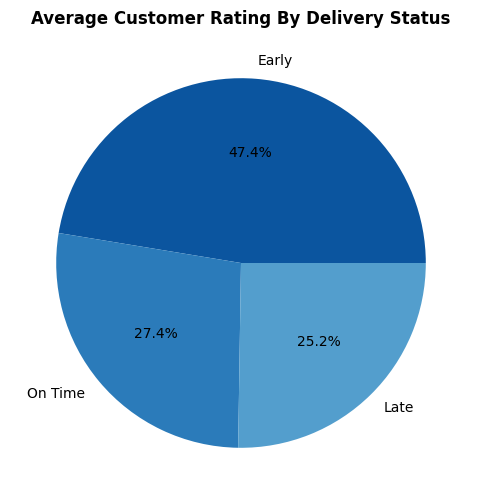

In [64]:
# Visualize the Average Customer Rating By Delivery Status
plt.figure(figsize=(12,6))
plt.pie(
    avg_review.values,
    labels=avg_review.index,
    autopct="%1.1f%%",
    colors=sns.color_palette("Blues_r"),
)
plt.title("Average Customer Rating By Delivery Status", weight="bold")
plt.show()

In [65]:
# Calculate average review the order status
avg_review_os = (
    df.groupby("order_status")["review_score"]
    .mean()
    .sort_values(ascending=False)
    .round(3)
)
avg_review_os

,review_score
order_status,
delivered,4.123
approved,2.500
created,2.333
shipped,1.993
canceled,1.818
invoiced,1.671
unavailable,1.521
processing,1.288


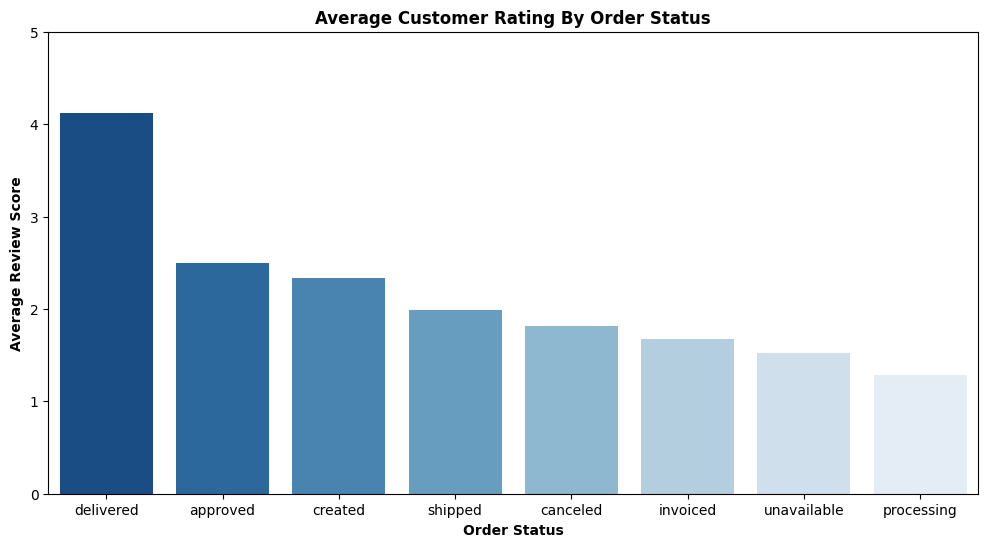

In [66]:
# Visualize Average Customer Rating By Order Status
plt.figure(figsize=(12,6))
sns.barplot(
    x=avg_review_os.index,
    y=avg_review_os.values,
    hue=avg_review_os.index,
    palette="Blues_r",
)
plt.title("Average Customer Rating By Order Status", weight="bold")
plt.xlabel("Order Status", weight="bold")
plt.ylabel("Average Review Score", weight="bold")
plt.ylim(0,5)
plt.show()

### Key Findings:
* The highest average reviews score (4.26) came for early deliveries.
* On-time deliveries averaged 2.46
* The lowest average rating was in the late deliveries (2.27)
* Delivered orders had the highest customer rating (4.12) while Processing orders had the lowest customer rating (1.29) amoung overall oder statuses.
### Business Insight:
The results reveal that there is a definite correlation between delivery performance and customer satisfaction. Meeting deliveries on time or before the expected date can get higher rating from ustomers, which shows the need for maintaining reliability with logistics and timely deliveries.

## Q5. What seasonal purchasing trends exist across months?
### Business Objective:
Understand that there is a seasonal demand by knowing the months of highest and lowest revenue to assist in sales planning.

In [67]:
# Display first 3 rows
df.head(3)

,order_id,order_status,order_date,delivery_date,estimated_delivery_date,customer_unique_id,customer_city,customer_state,product_id,product_category,...,review_score,is_delivered,has_review,order_year,order_month_name,order_day_name,order_hour,revenue,delivery_delay,delivery_status
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,87285b34884572647811a353c7ac498a,housewares,...,4.0,True,True,2017,October,Monday,10,29.99,-8.0,Early
1,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,87285b34884572647811a353c7ac498a,housewares,...,4.0,True,True,2017,October,Monday,10,29.99,-8.0,Early
2,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,87285b34884572647811a353c7ac498a,housewares,...,4.0,True,True,2017,October,Monday,10,29.99,-8.0,Early


In [68]:
# Calculate monthly revenue by order month name
monthly_revenue = (
    df.groupby("order_month_name")["revenue"]
    .sum()
)
monthly_revenue

,revenue
order_month_name,
April,1335212.46
August,1402685.94
December,732792.15
February,1062887.18
January,1046862.22
July,1357605.08
June,1276977.21
March,1331638.82
May,1462167.86


In [69]:
# Calculate monthly revenue in chronological order
month_name_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December"
]
df["order_month_name"] = pd.Categorical(
    df["order_month_name"],
    categories=month_name_order,
    ordered=True
)
monthly_revenue = (
    df.groupby("order_month_name")["revenue"]
    .sum()
    .sort_index()
)
monthly_revenue

/tmp/ipykernel_4420/866951475.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("order_month_name")["revenue"]


,revenue
order_month_name,
January,1046862.22
February,1062887.18
March,1331638.82
April,1335212.46
May,1462167.86
June,1276977.21
July,1357605.08
August,1402685.94
September,598959.16


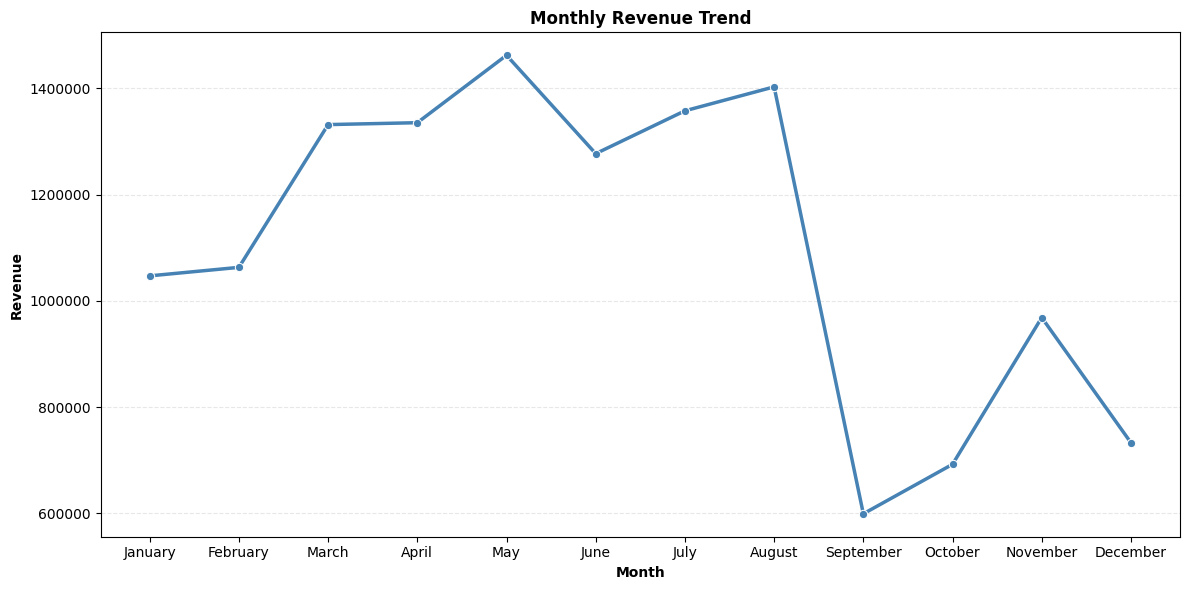

In [70]:
# visualize Monthly Revenue Trend
plt.figure(figsize=(12,6))
sns.lineplot(
    x=monthly_revenue.index,
    y=monthly_revenue.values,
    marker="o",
    linewidth=2.5,
    color="steelblue"
)
plt.title("Monthly Revenue Trend", weight="bold")
plt.xlabel("Month", weight="bold")
plt.ylabel("Revenue", weight="bold")
plt.ticklabel_format(style="plain", axis="y")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

### Key Findings:
* The highest revenue was made in the month of May (1,462,168).
* The revenue was also very good for both August and July, with each month having over 1.35 million.
* October and December had the lowest revenues, followed by september (598,959).
* Revenue was generally good through top August but dropped considerably in Septeber.
### Business Insight:
Sales are best in the March-August period. These months should be taken into consideration at the time of planning inventory, marketing campaigns and promotions, while other sales strategies can help increase sales during less busy months like September or october.

## Q6. Which product categories consistently receive the highest and lowest customer ratings?
### Business Objective:
Determine product categories that have consistently high or low ratings from customers to help improve the quality of the products and customer satisfaction.

In [71]:
# Calculate category rating
category_rating = (
    df.groupby("product_category")["review_score"]
    .agg(["mean", "count"]).round(3)
    .rename(columns={
        "mean"  : "average_rating",
        "count" : "total_reviews"
    })
)
category_rating.sort_values("average_rating", ascending=False).head(10)

,average_rating,total_reviews
product_category,,
cds_dvds_musicals,4.667,12
fashion_childrens_clothes,4.500,8
books_general_interest,4.439,538
books_imported,4.410,61
costruction_tools_tools,4.396,96
food_drink,4.395,243
flowers,4.393,28
books_technical,4.379,264
la_cuisine,4.357,14


In [72]:
# Filter categories with atleast 50 reviews
category_rating = category_rating[category_rating["total_reviews"]>=50]
# Remove unknown categories
category_rating = category_rating.drop(index="Unknown")

In [73]:
# Select top 10 rating
top10_rating = (
    category_rating
    .sort_values("average_rating", ascending=False)
    .head(10)
)
top10_rating

,average_rating,total_reviews
product_category,,
books_general_interest,4.439,538
books_imported,4.410,61
costruction_tools_tools,4.396,96
food_drink,4.395,243
books_technical,4.379,264
small_appliances_home_oven_and_coffee,4.321,78
luggage_accessories,4.312,1105
food,4.274,460
stationery,4.229,2436


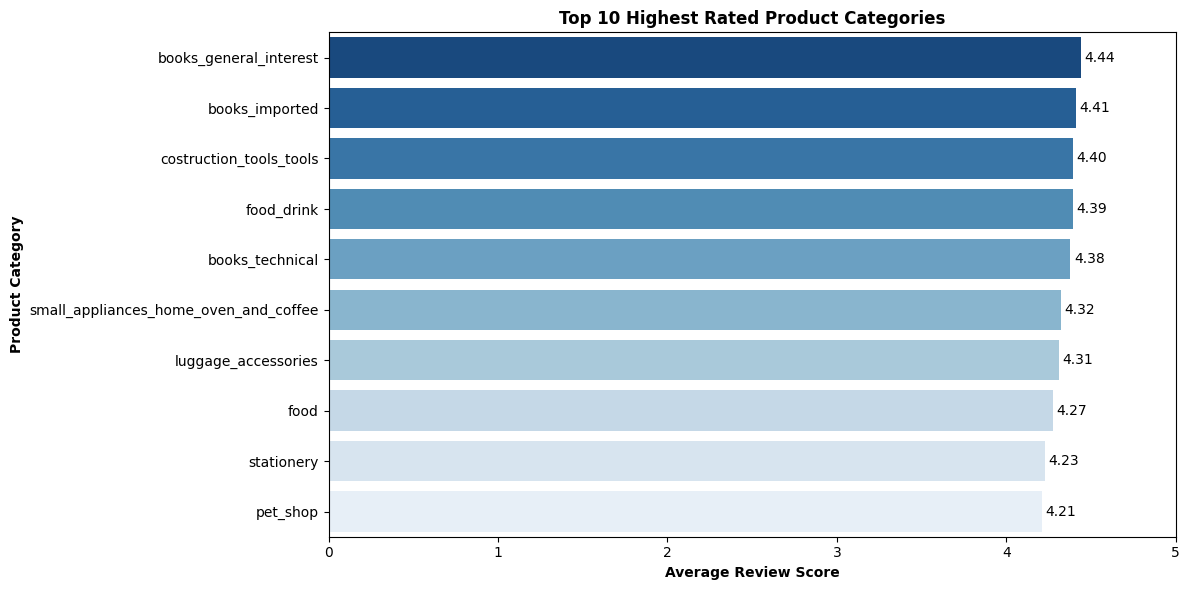

In [74]:
# Visualize Top 10 Highest Rated Product Categories
plt.figure(figsize=(12,6))
ax = sns.barplot(
    data = top10_rating,
    x="average_rating",
    y = top10_rating.index,
    hue = top10_rating.index,
    palette = "Blues_r",
)
for i, v in enumerate(top10_rating["average_rating"]):
  ax.text(v + 0.02, i, f"{v:.2f}", va="center")

plt.title("Top 10 Highest Rated Product Categories", weight="bold")
plt.xlabel("Average Review Score", weight="bold")
plt.ylabel("Product Category", weight="bold")
plt.xlim(0,5)
plt.tight_layout()
plt.show()

### Bottom 10 Lowest-rated Categories

In [75]:
# Calculate lowest 10 rating
lowest10_rating = (
    category_rating
    .sort_values("average_rating", ascending=True)
    .head(10)
)
lowest10_rating

,average_rating,total_reviews
product_category,,
fashion_male_clothing,3.538,132
office_furniture,3.605,1350
audio,3.837,362
construction_tools_safety,3.867,173
fixed_telephony,3.877,220
bed_bath_table,3.908,10672
home_confort,3.926,445
fashion_underwear_beach,3.938,129
home_construction,3.958,526


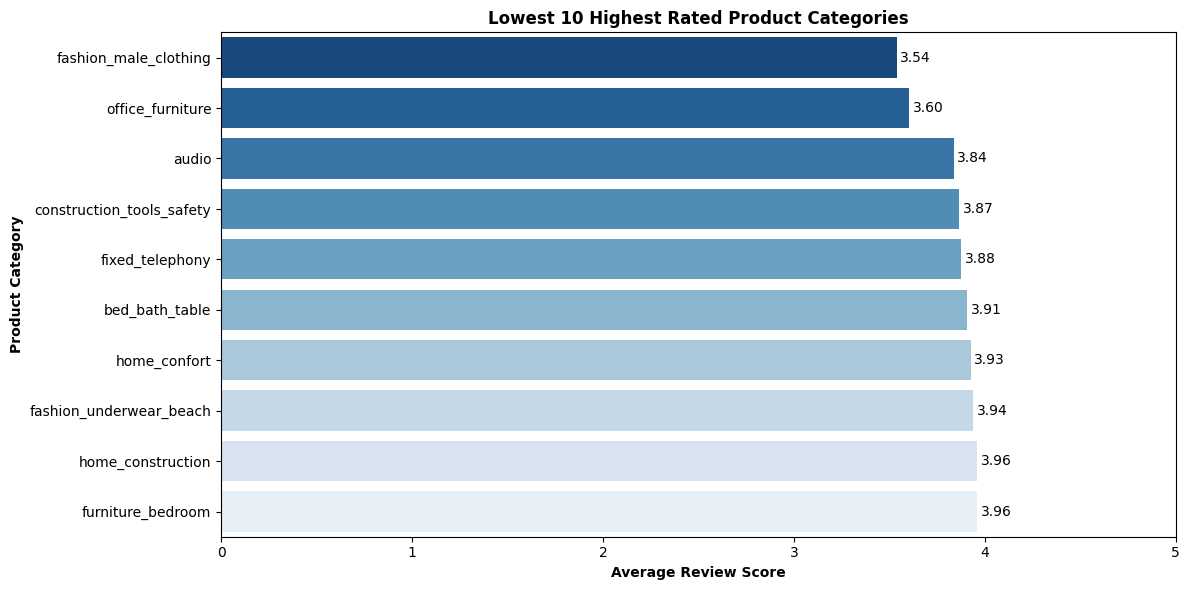

In [76]:
# Visualize Lowest 10 Highest Rated Product Categories
plt.figure(figsize=(12,6))
ax = sns.barplot(
    data = lowest10_rating,
    x="average_rating",
    y = lowest10_rating.index,
    hue = lowest10_rating.index,
    palette = "Blues_r",
)
for i, v in enumerate(lowest10_rating["average_rating"]):
  ax.text(v + 0.02, i, f"{v:.2f}", va="center")

plt.title("Lowest 10 Highest Rated Product Categories", weight="bold")
plt.xlabel("Average Review Score", weight="bold")
plt.ylabel("Product Category", weight="bold")
plt.xlim(0,5)
plt.tight_layout()
plt.show()

### Key Findings:
Highest-rated categories:
* The highest average rating(4.44) was for Books General Interest.
* The other categories, Book Imported, Construction Tools, and Food Drink continued to rate well above 4.39.
* The rating were more reliable since all the top-rated categories had a minimum of 50 customer reviews.

Lowest-rated Categories
* The average rating was lowest for Fashion Male Clothing (3.54).
* Office Furniture and Audio were next with scores of 3.60 and 3.84 respectively.
* Even though Bed Bath Table had a lot of reviews, it had a lower rating (3.91), which could be a quality or service problem.

### Business Insight:
The best rated categories indecate high customer satisfaction and should be kept upto used as quality measures. Products in low rated categories should be given attention to improve product quality and customer experience, especially those with more reviews.

## Q7. Which cities generate the largest order volume and highest customer value?
Recognize the cities where the most orders are placed and the value customers place on them to guide regional sales and marketing strategies.

In [77]:
# Create summary of order volume and customer value
city_summary = (
    df.groupby("customer_city")
    .agg(
        order_volume    = ("order_id", "nunique"),
        customer_value  = ("revenue", "sum")
    )
)
city_summary.head(10)

,order_volume,customer_value
customer_city,,
abadia dos dourados,3,358.90
abadiania,1,949.99
abaete,12,1732.81
abaetetuba,11,3698.67
abaiara,2,262.90
abaira,2,157.99
abare,2,185.19
abatia,3,167.89
abdon batista,1,125.40


In [78]:
# Top 10 cities by order volume
top_oder_cities = (
    city_summary
    .sort_values("order_volume", ascending=False)
    .head(10)
)
top_oder_cities

,order_volume,customer_value
customer_city,,
sao paulo,15540,1859160.48
rio de janeiro,6882,952077.90
belo horizonte,2773,348278.25
brasilia,2131,297683.19
curitiba,1521,202369.14
campinas,1444,182644.51
porto alegre,1379,177720.21
salvador,1245,176339.96
guarulhos,1189,143090.18


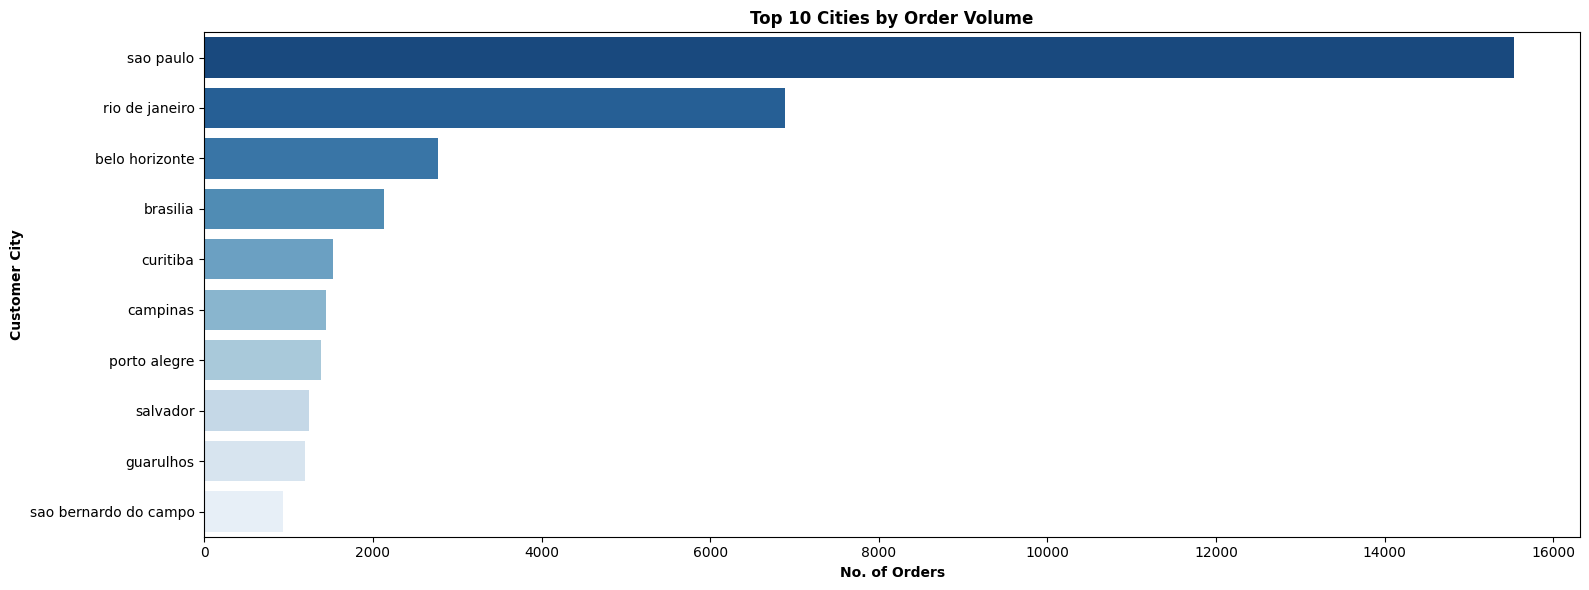

In [79]:
# Visualize Top 10 Cities by Order Volume
plt.figure(figsize=(16,6))
sns.barplot(
    data=top_oder_cities,
    x="order_volume",
    y=top_oder_cities.index,
    hue=top_oder_cities.index,
    palette="Blues_r"
)
plt.title("Top 10 Cities by Order Volume", weight="bold")
plt.xlabel("No. of Orders", weight="bold")
plt.ylabel("Customer City", weight="bold")
plt.tight_layout()
plt.show()

#### Top 10 Cities by Customer Value

In [80]:
# Identify the Top 10 cities with highest customer value
top_value_cities = (
    city_summary
    .sort_values("customer_value", ascending=False)
    .head(10)
)
top_value_cities

,order_volume,customer_value
customer_city,,
sao paulo,15540,1859160.48
rio de janeiro,6882,952077.90
belo horizonte,2773,348278.25
brasilia,2131,297683.19
curitiba,1521,202369.14
campinas,1444,182644.51
porto alegre,1379,177720.21
salvador,1245,176339.96
guarulhos,1189,143090.18


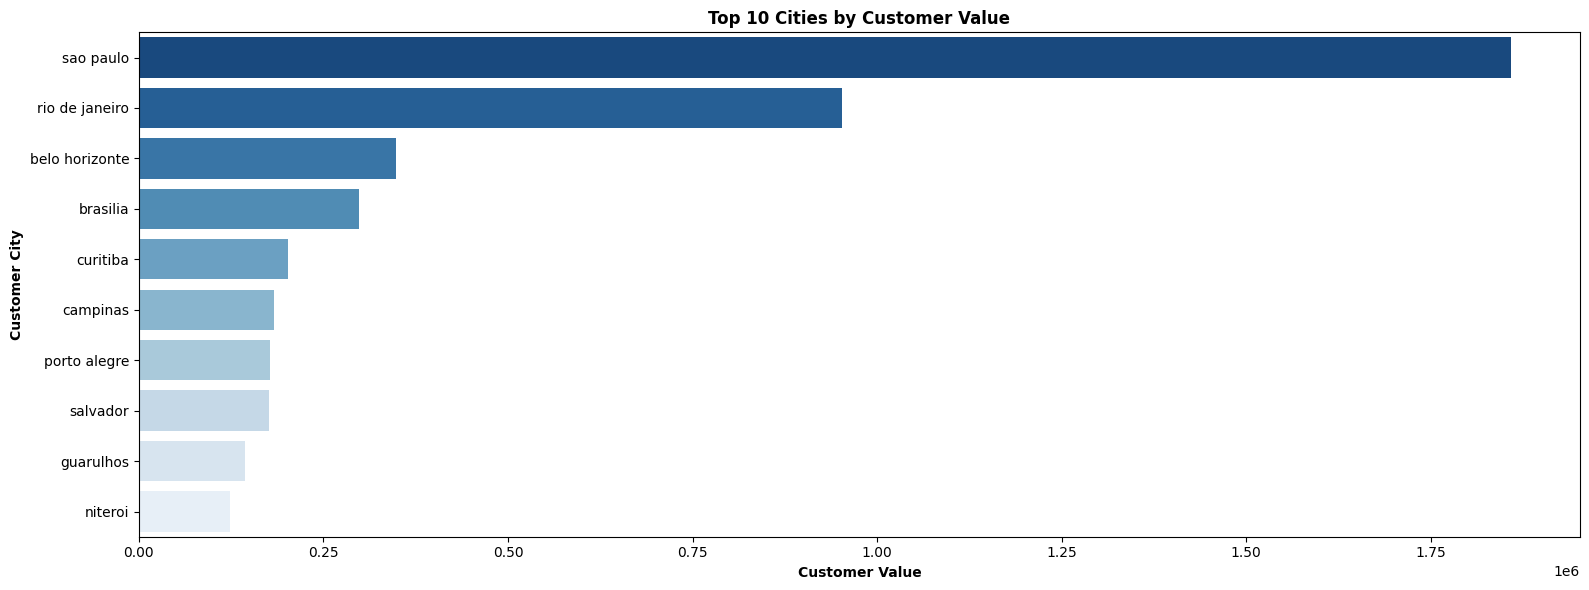

In [81]:
# Visualize Top 10 Cities by Customer Value
plt.figure(figsize=(16,6))
sns.barplot(
    data=top_value_cities,
    x="customer_value",
    y=top_value_cities.index,
    hue=top_value_cities.index,
    palette="Blues_r"
)
plt.title("Top 10 Cities by Customer Value", weight="bold")
plt.xlabel("Customer Value", weight="bold")
plt.ylabel("Customer City", weight="bold")
plt.tight_layout()
plt.show()

### Key Findings:
* with 15,540 orders and customer value of 1,859,161, there was a highest order volume and customer value in the city of Sao Paulo.
* The second place was with Rio de Janeiro that had 6882 orders and 952078 in customer value.
* The cities of Belo Horizonte, Brasilia and Curitiba also had good results in both customer demand and revenue.
* A major propotion of the total sales in achieved by the top 10 cities.

### Business Insight:
The company's most promising markets are located in the major metropolitan areas, especially Sao Pulo and Rio de Jeneiro. These should continue to be the primary cities to focus on for customer acquisition, logistic optimization, and potential future expansion.

## Q8. Which product categories experience the longest average delivery delays?
### Business Objective:
Determine the delay time for each product tye and identify the product tye with the longest delay time, to optimize logistics planning and decrease late delivery of products.

In [82]:
# Calculate average delivery delay
category_delay = (
    df[df["delivery_status"] == "Late"]
    .groupby("product_category")["delivery_delay"]
    .agg(["mean", "count"])
    .rename(columns={
        "mean"  : "average_delay",
        "count" : "late_orders"
    })
)
# Selecting product categories with at least 5 late oders
category_delay = category_delay[category_delay["late_orders"] >= 5]
category_delay = category_delay.sort_values("average_delay", ascending=False)
category_delay.head(10)

,average_delay,late_orders
product_category,,
home_appliances_2,21.928571,14
signaling_and_security,17.833333,6
furniture_mattress_and_upholstery,15.200000,5
food_drink,14.875000,8
christmas_supplies,14.700000,10
office_furniture,14.009346,107
food,13.484848,33
home_confort,13.368421,38
air_conditioning,12.500000,10


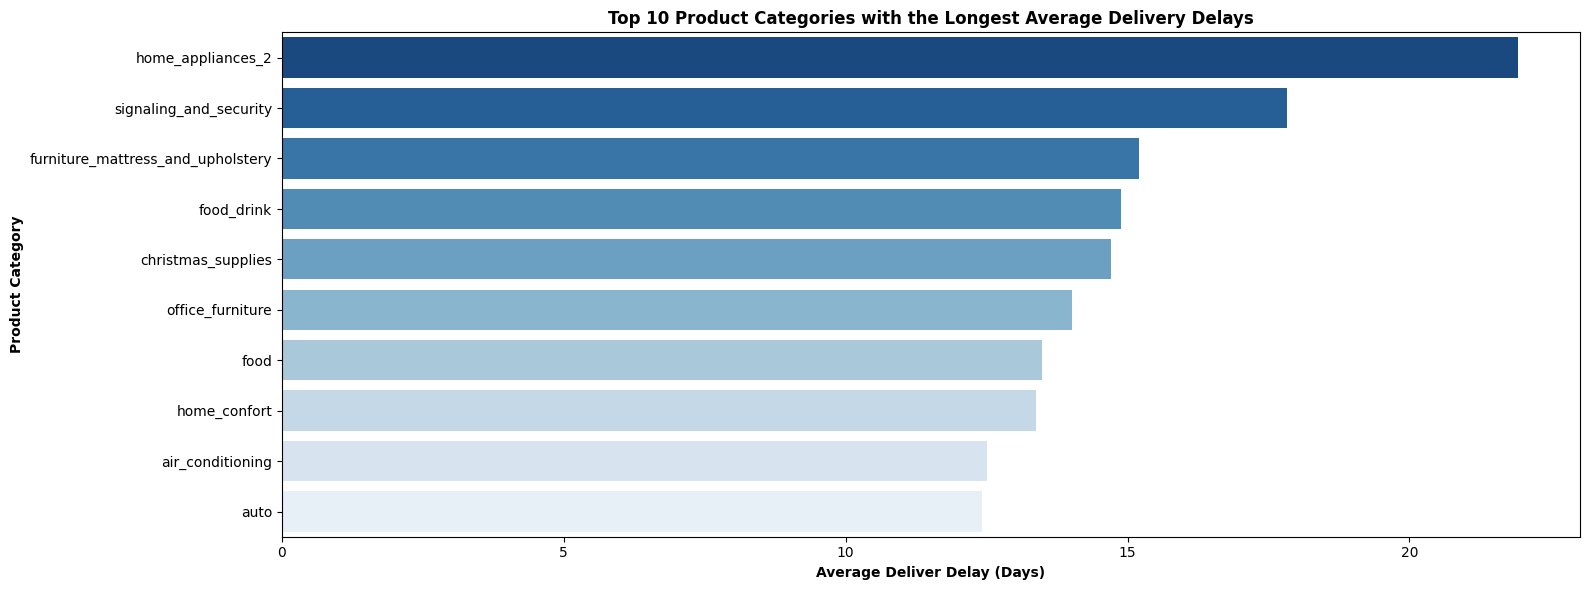

In [83]:
# Visualize Top 10 Product Categories with the Longest Average Delivery Delays
plt.figure(figsize=(16,6))
sns.barplot(
    x=category_delay.head(10)["average_delay"],
    y=category_delay.head(10).index,
    hue=category_delay.head(10).index,
    palette="Blues_r"
)
plt.title("Top 10 Product Categories with the Longest Average Delivery Delays", weight="bold")
plt.xlabel("Average Deliver Delay (Days)", weight="bold")
plt.ylabel("Product Category", weight="bold")
plt.tight_layout()
plt.show()

### Key Findings:
* The average delay for Home Appliances 2 was the longest at 21.93 days.
* Signaling and Security came in second with an average delay of 17.83 days.
* The furniture mattress and upholstery, food drink and Christmas Supplies were between approximately 14-15 days late.
* For reliable results, analysis only considers with 5 or more late orders.

### Business Insight:
Product categories with regularly long delivery lead times should be coordeinated with suppliers, planned in stock and should be optimized through logistics to avoid that customers wait for products and to improve delivery performance.

## Q9. What proportion of orders fail before delivery, and which order statuses require operational improvement?

Analyze the distribution of order statuses to determine the number of successful orders and which order statuses are not delivered signifying problem in the operations.

In [84]:
# Calculate the percentage distribution of orders by order status
order_status_summary = (
    df.groupby("order_status")["order_id"]
    .nunique()
    .sort_values(ascending=False)
)
order_status_summary

,order_id
order_status,
delivered,96477
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


In [85]:
# Calculate Percentages
order_status_percentages = (
    order_status_summary / order_status_summary.sum() *100
).round(3)
order_status_percentages

,order_id
order_status,
delivered,97.020
shipped,1.113
canceled,0.629
unavailable,0.612
invoiced,0.316
processing,0.303
created,0.005
approved,0.002


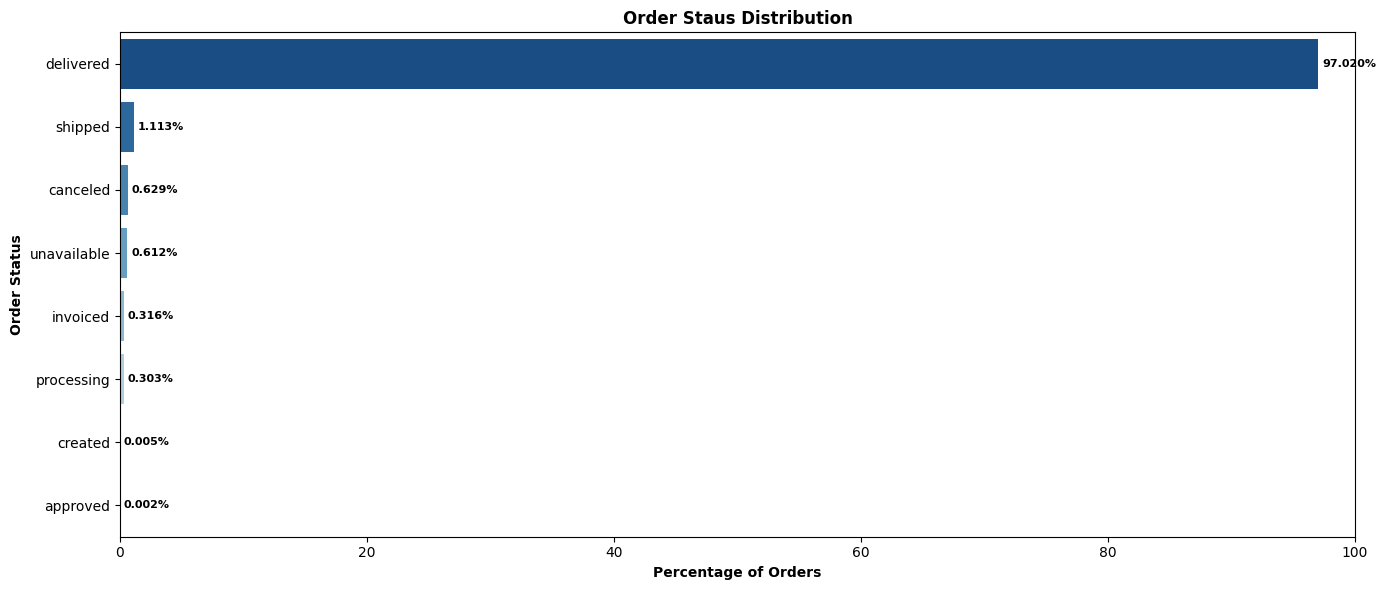

In [86]:
# Visualize Order Staus Distribution
plt.figure(figsize=(14,6))
ax = sns.barplot(
    x=order_status_percentages.values,
    y=order_status_percentages.index,
    hue=order_status_percentages.index,
    palette="Blues_r"
)
for i, v in enumerate(order_status_percentages.values):
  ax.text(v + 0.3, i, f"{v:.3f}%", va="center", fontsize=8, weight="bold")

plt.title("Order Staus Distribution", weight="bold")
plt.xlabel("Percentage of Orders", weight="bold")
plt.ylabel("Order Status", weight="bold")
plt.xlim(0,100)
plt.tight_layout()
plt.show()

### Business Insights:
The analysis reveals that the overall performance f the operation has been good, with 97.02% of all orders delivered successfully. Orders that were not completed were 2.98%, the largest non-delivered orders being shipped (1.11%). Cancelled (0.63%) and unavailable (0.61%). Most of the categories in which getting better at inventory management, order fulfillment and delivery operations could lower the number of failed orders.

## Q10. Which seller contribute most late deliveries?
### Business Objective:
Prolonged delivery performance data to support suppliers performance monitoring and logistics improvements, and identify the sellers that have the most late deliveries.

In [87]:
# Calculate the top 10 sellers with most late deliveries
seller_delay = (
    df[df['delivery_status']=="Late"]
    .groupby("seller_id")
    .agg(
        late_orders   = ("order_id", "nunique"),
        average_delay = ("delivery_delay", "mean")
    )
    .sort_values("late_orders", ascending=False)
)
top_seller_delay = seller_delay.head(10)
top_seller_delay

,late_orders,average_delay
seller_id,,
4a3ca9315b744ce9f8e9374361493884,172,11.478261
1f50f920176fa81dab994f9023523100,124,10.654676
4869f7a5dfa277a7dca6462dcf3b52b2,118,9.336000
6560211a19b47992c3666cc44a7e94c0,96,7.598131
ea8482cd71df3c1969d7b9473ff13abc,96,7.960784
7c67e1448b00f6e969d365cea6b010ab,89,13.273684
cc419e0650a3c5ba77189a1882b7556a,87,7.902174
da8622b14eb17ae2831f4ac5b9dab84a,87,11.170213
8b321bb669392f5163d04c59e235e066,81,10.132530


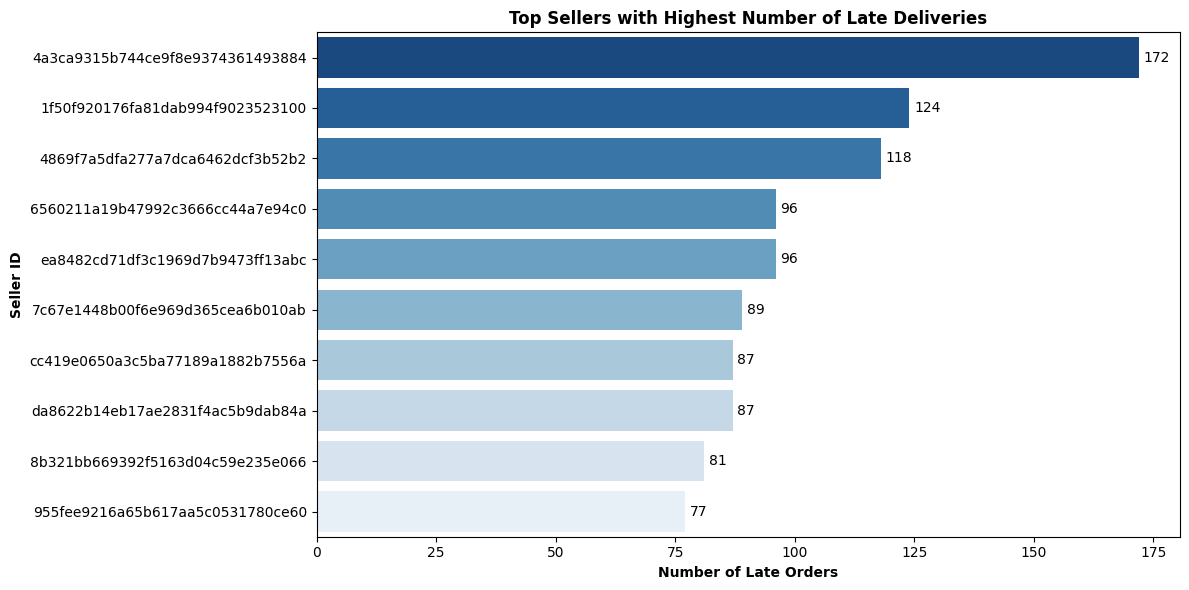

In [89]:
# Visualize Top Sellers with Highest Number of Late Deliveries
plt.figure(figsize=(12,6))
ax = sns.barplot(
    x=top_seller_delay["late_orders"],
    y=top_seller_delay.index,
    hue=top_seller_delay.index,
    palette="Blues_r"
)
for i, v in enumerate(top_seller_delay["late_orders"]):
  ax.text(v+1,i, f"{v}", va="center")

plt.title("Top Sellers with Highest Number of Late Deliveries", weight="bold")
plt.xlabel("Number of Late Orders", weight="bold")
plt.ylabel("Seller ID", weight="bold")
plt.tight_layout()
plt.show()

### Business Insights:
The findings indicate a few sellers are accountable for late deliveries to a large extent. The first position with 172 late orders, the next seller with 124 late orders and the next leading seller with 118 late orders. Such high-delay sellers should be tracked to enhance delivery reliability, such as through supplier management and performance reviews.

# Key Findings
Several significant trends were discovered in customer buying patterns and business performance. Health & Beauty was the top revenue generating product category, with the highest contribution to total revenue. It was in Sao Paulo that the company made te most revenue and received the most orders, making it the most profitable region market.

Customer spending was greatest for credit card payments, indicating that customers are more likely to spend bigger amounts on this method of payment. The study also revealed a strong correlation between the delivery performance and customer satisfaction. Early deliveries were consistently rated highest and late deliveries lowest.

Sales were seasonal, with sales volume reaching a peak in May and contributing to be strong through the middle of the year. Last but not least, while 97% of orders were fulfilled on time, certain sellers did a bad job on same orders, in this case, there was an opportunity to make a better job to improve on supplier delivery.

# Business Recommendations:
Following these findings, the following recommendations are made;

* **Invest in top-performing categories**, by boosting inventory and peromotions in Health & Beauty and other top product categories.
* **Promote regional growth** by focusing on marketing and customer acquisition in the states of Sao Paulo, Rio de Jeneiro and Minas Gerais.
* **Enhance the performance of logistics** by minimizing delivery delays for some categories with a delivery lead time, such as Home Appliances and Furnitures.
* **Regularly evaluate sellers behaviour** and take corrective action as needed for sellers that are delivering late deliveries.
* **Improve delivery reliability** to create better customer experience. Delay can have a strong influence on customer satisfaction and review scores.

# Conclusion
In this project, we investigated the behaviour of customers with respect to the purchase and the operational performance of the company by converting the data of orders, customers, products, payments, reviews and sellers into a single analytical dataset and providing insights into the same. This analysis involved data cleaning, feature engineering, exploratory data analysis, and visualization, which helped convert the raw transactional data into meaningful business insights.

The results indicate that revenue is focused in a few product categories and key urban centers. However, Health & Beauty was the top revenue generating category and the market of Sao Paulo is the company's leading one in terms of sales and customer value. There were also distinct trends in the seasonal nature of purchase identified, with clear purchaseing patterns of high demand in the middle of the year, which is a healpful for inventory planning and promotional strategies.

Deliverability directly affects the customer's satisfaction in an operational manner. Deliveries that were made early were as a matetr of rule, the one that got the best reviews, while the late deliveries got the lowest ratings. While about 97% of the orders were successfully delivered, certain product categories and sellers accounted for a significant portion of the delivery delays, highlighting specific areas that need to be improved in logistics and supplier management.

The project provides an overall example of the support that data analytics can provide in evidence based business decision making. The knowledge produced can be used to guide management to manage product investments more effectively, prioritize high value markets, increase the delivery reliablility, improve the seller performance, and improve overall customer exeperinec. The findings will prove to be a practical basis for creating improved marketing, operational and customer retension strategies for e-commerce.

# References:
Dataset
* Kaggle Olist Dataset : https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce

Learning Resources

* Geekforgeeks - Datetime: https://www.geeksforgeeks.org/python/python-datetime-module/
* Geekforgeeks - Data Visualization: https://www.geeksforgeeks.org/data-visualization/data-visualization-with-python-seaborn/
* Geekforgeeks - Data Analysis (groupby function): https://www.geeksforgeeks.org/pandas/how-to-combine-groupby-and-multiple-aggregate-functions-in-pandas/
* W3Schools- Data Handling and Manipulation: https://www.w3schools.com/python/default.asp


In [92]:
# Export notebbok as .html file
!jupyter nbconvert --to html "/content/drive/MyDrive/Gisma/Q 2/AI & Applications/Customer_Purchasing_Behaviour_and_Operational_Performance_Analysis.ipynb"

[NbConvertApp] WARNING | pattern '/content/drive/MyDrive/Gisma/Q 2/AI & Applications/Customer_Purchasing_Behaviour_and_Operational_Performance_Analysis.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer 